# DVF EDA - Houses Mutations France (2020-2025)
# Author: Xavier VAN AUSLOOS, 14/02/26
# Exploratory Data Analysis on cleaned dataset: df_grouped_2020_2025_france_cleaned.csv

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Data & Basic Info

In [104]:
df = pd.read_csv(
    "../data/processed/df_grouped_2020_2025_france_cleaned.csv",
    low_memory=False
)
print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

Shape: (2502263, 42)

Columns (42):
['Identifiant de document', 'Reference document', '1 Articles CGI', '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI', 'No disposition', 'Nature mutation', 'No voie', 'B/T/Q', 'Type de voie', 'Code voie', 'Voie', 'Code postal', 'Commune', 'Code departement', 'Code commune', 'Prefixe de section', 'Section', 'No plan', 'No Volume', '1er lot', 'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot', '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot', 'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot', 'Nombre de lots', 'Code type local', 'Type local', 'Identifiant local', 'Surface reelle bati', 'Nombre pieces principales', 'Nature culture', 'Nature culture speciale', 'Surface terrain', 'mutations']


In [105]:
df.dtypes

Identifiant de document       float64
Reference document            float64
1 Articles CGI                float64
2 Articles CGI                float64
3 Articles CGI                float64
4 Articles CGI                float64
5 Articles CGI                float64
No disposition                  int64
Nature mutation                   str
No voie                       float64
B/T/Q                             str
Type de voie                      str
Code voie                         str
Voie                              str
Code postal                   float64
Commune                           str
Code departement                  str
Code commune                    int64
Prefixe de section            float64
Section                           str
No plan                         int64
No Volume                     float64
1er lot                           str
Surface Carrez du 1er lot         str
2eme lot                          str
Surface Carrez du 2eme lot        str
3eme lot    

In [106]:
df.describe()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,No voie,Code postal,Code commune,Prefixe de section,No plan,No Volume,3eme lot,4eme lot,5eme lot,Nombre de lots,Code type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Surface terrain
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.502263e+06,2.493854e+06,2.502128e+06,2.502263e+06,92976.000000,2.502263e+06,0.0,4463.000000,2298.000000,1306.000000,2.502263e+06,2502263.0,0.0,2.502126e+06,2.502126e+06,2.426747e+06
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.039963e+00,7.117942e+02,4.985702e+04,2.226108e+02,327.509992,4.169741e+02,NaN,31.586825,39.657528,20.934916,2.678495e-02,1.0,NaN,1.014998e+02,4.191344e+00,7.210424e+02
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.871293e-01,1.870872e+03,2.625907e+04,1.749671e+02,261.230722,5.543674e+02,NaN,635.003227,880.487036,79.062706,2.550143e-01,0.0,NaN,4.509721e+01,1.502051e+00,3.890210e+03
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.000000e+00,1.000000e+03,1.000000e+00,1.000000,1.000000e+00,NaN,2.000000,2.000000,2.000000,0.000000e+00,1.0,NaN,1.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,8.000000e+00,2.934000e+04,8.300000e+01,133.000000,9.800000e+01,NaN,4.000000,4.000000,5.000000,0.000000e+00,1.0,NaN,7.400000e+01,3.000000e+00,2.490000e+02
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,2.200000e+01,4.950000e+04,1.850000e+02,251.000000,2.300000e+02,NaN,6.000000,6.000000,6.000000,0.000000e+00,1.0,NaN,9.400000e+01,4.000000e+00,4.950000e+02
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.010000e+02,7.260000e+04,3.180000e+02,466.000000,5.090000e+02,NaN,12.000000,12.000000,13.000000,0.000000e+00,1.0,NaN,1.200000e+02,5.000000e+00,7.810000e+02
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.300000e+02,9.999000e+03,9.749000e+04,9.090000e+02,950.000000,9.914000e+03,NaN,42003.000000,42004.000000,1705.000000,3.800000e+01,1.0,NaN,3.160000e+03,1.980000e+02,3.760000e+06


In [107]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df.sort_values('missing_pct', ascending=False)
print("Missing values (showing columns with any missing):")
missing_df[missing_df['missing_count'] > 0]

Missing values (showing columns with any missing):


,missing_count,missing_pct
Identifiant de document,2502263,100.00
4 Articles CGI,2502263,100.00
Identifiant local,2502263,100.00
Reference document,2502263,100.00
5 Articles CGI,2502263,100.00
No Volume,2502263,100.00
3 Articles CGI,2502263,100.00
2 Articles CGI,2502263,100.00
1 Articles CGI,2502263,100.00
Surface Carrez du 5eme lot,2502117,99.99


In [108]:
df.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Nature mutation,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,mutations
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,1384.0,NaN,CHE,0088,DE LA CHAMBIERE,1000.0,SAINT-DENIS-LES-BOURG,1,344,NaN,A,933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,140.0,7.0,S,NaN,1347.0,"[{'22/07/2021': '262000,00'}, {'20/05/2022': '260000,00'}]"
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,1620.0,NaN,CHE,0088,DE LA CHAMBIERE,1000.0,SAINT-DENIS-LES-BOURG,1,344,NaN,A,2307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,138.0,5.0,J,NaN,510.0,"[{'29/07/2024': '200000,00'}]"
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,20.0,NaN,RUE,1140,DENIS PAPIN,1000.0,BOURG-EN-BRESSE,1,53,NaN,AB,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,74.0,4.0,J,POTAG,755.0,"[{'22/10/2024': '226700,00'}]"
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,12.0,NaN,RUE,1140,DENIS PAPIN,1000.0,BOURG-EN-BRESSE,1,53,NaN,AB,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,81.0,5.0,S,NaN,637.0,"[{'29/09/2021': '240000,00'}]"
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,692.0,NaN,CHE,0330,DES OURES,1000.0,SAINT-DENIS-LES-BOURG,1,344,NaN,AB,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,167.0,4.0,J,NaN,560.0,"[{'01/07/2024': '249000,00'}]"


**Interpretation — Load Data & Basic Info**

- **Scale**: ~2.5M house mutations (2020–2025), one row per grouped property (cadastral reference).
- **Key numeric variables**: `Surface reelle bati` (median ~94 m²), `Nombre pieces principales` (median 4), `Surface terrain` (median ~495 m²). Building surface and room count are almost complete; terrain has ~3% missing.
- **Missingness**: Many administrative/Cadastre fields (e.g. Articles CGI, Identifiant local, lot/Carrez) are 100% or nearly 100% missing and can be ignored for price/surface EDA. Only `Surface terrain`, `Nature culture`, `Type de voie`, and a few others have non-trivial missingness; core modelling variables are well populated.

## 2. Parse Mutations (prices & dates)

In [109]:
def parse_mutations(mutations_str):
    """Parse mutations string into list of (date, price) tuples."""
    try:
        mutations = ast.literal_eval(mutations_str)
        results = []
        for m in mutations:
            if isinstance(m, dict):
                for date_str, price_str in m.items():
                    date = datetime.strptime(date_str, '%d/%m/%Y')
                    price = float(price_str.replace(',', '.'))
                    results.append((date, price))
        return results
    except:
        return []

df['parsed_mutations'] = df['mutations'].apply(parse_mutations)
df['nb_mutations'] = df['parsed_mutations'].apply(len)

# Extract last mutation price and date for each property
df['last_price'] = df['parsed_mutations'].apply(lambda x: x[-1][1] if x else np.nan)
df['last_date'] = df['parsed_mutations'].apply(lambda x: x[-1][0] if x else pd.NaT)
df['first_price'] = df['parsed_mutations'].apply(lambda x: x[0][1] if x else np.nan)
df['first_date'] = df['parsed_mutations'].apply(lambda x: x[0][0] if x else pd.NaT)

print(f"Properties with parsed mutations: {(df['nb_mutations'] > 0).sum():,}")
print(f"Properties with multiple mutations: {(df['nb_mutations'] > 1).sum():,}")

Properties with parsed mutations: 2,502,263
Properties with multiple mutations: 173,234


**Interpretation — Parse Mutations**

- All ~2.5M properties have at least one parsed mutation (price and date extracted).
- ~173k properties (≈7%) have multiple mutations (repeat sales), enabling repeat-sales and price-change analysis later in the notebook.

## 3. Price Distribution

In [110]:
print("Last mutation price statistics:")
print(df['last_price'].describe())
print(f"\nMedian: {df['last_price'].median():,.0f} €")

Last mutation price statistics:
count    2.498959e+06
mean     3.721018e+05
std      4.648679e+06
min      1.500000e-01
25%      1.208000e+05
50%      2.000000e+05
75%      3.150000e+05
max      7.225900e+08
Name: last_price, dtype: float64

Median: 200,000 €


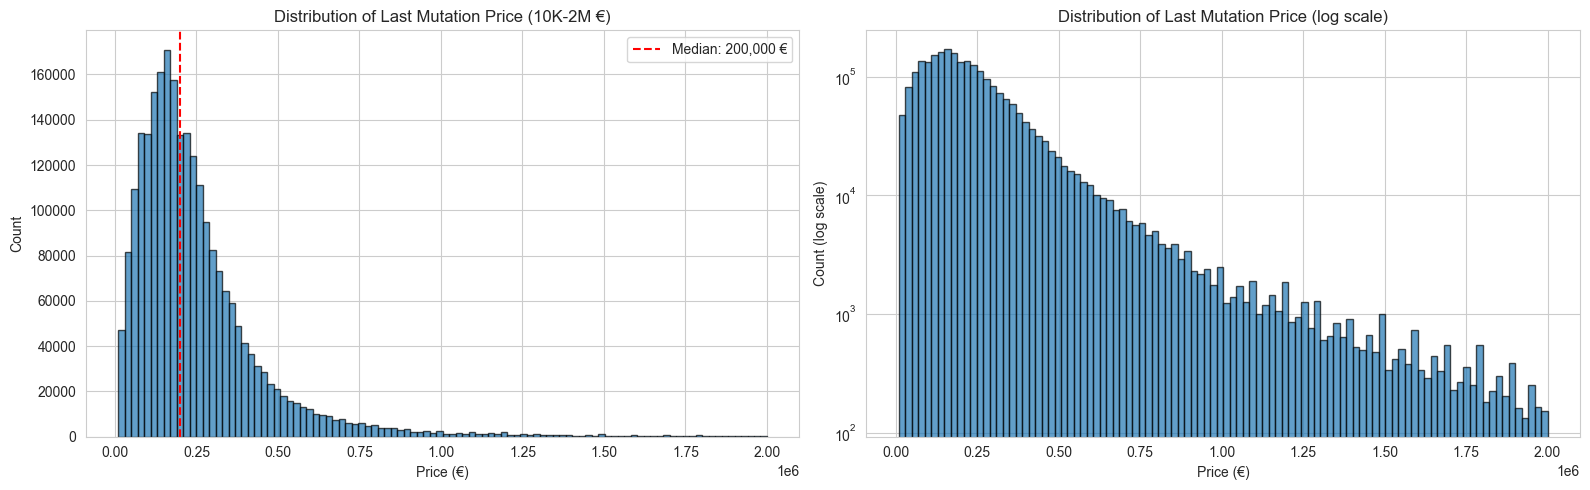

In [111]:
# Price distribution (filter outliers for readability)
price_mask = (df['last_price'] > 10_000) & (df['last_price'] < 2_000_000)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df.loc[price_mask, 'last_price'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Last Mutation Price (10K-2M €)')
axes[0].axvline(df.loc[price_mask, 'last_price'].median(), color='red', linestyle='--', label=f"Median: {df.loc[price_mask, 'last_price'].median():,.0f} €")
axes[0].legend()

axes[1].hist(df.loc[price_mask, 'last_price'], bins=100, edgecolor='black', alpha=0.7, log=True)
axes[1].set_xlabel('Price (€)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution of Last Mutation Price (log scale)')

plt.tight_layout()
plt.show()

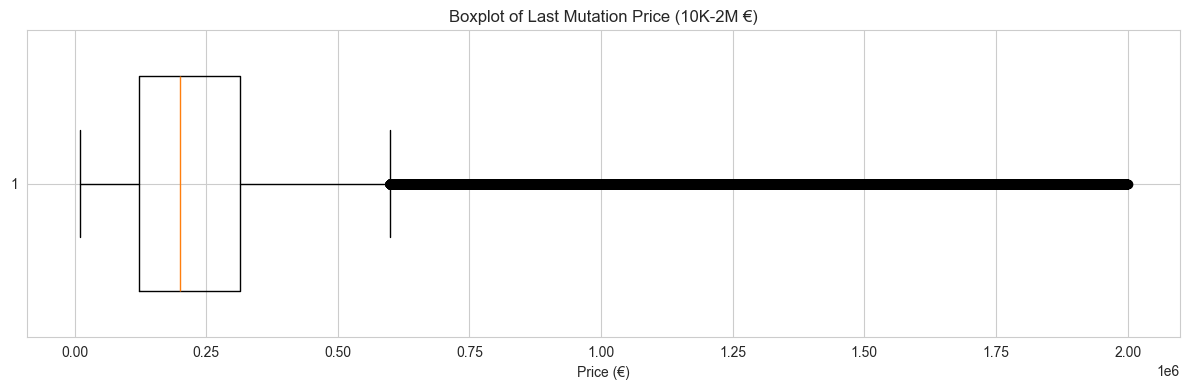

In [112]:
# Boxplot of prices
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(df.loc[price_mask, 'last_price'].dropna(), vert=False, widths=0.7)
ax.set_xlabel('Price (€)')
ax.set_title('Boxplot of Last Mutation Price (10K-2M €)')
plt.tight_layout()
plt.show()

**Interpretation — Price Distribution**

- **Central tendency**: Median last mutation price is **200 000 €**; mean is much higher (~372k €), indicating a right-skewed distribution pulled up by high-value transactions.
- **Spread**: Large standard deviation (~4.6M €) and max (722M €) show strong skew and outliers; the 10k–2M € filter focuses the histograms on the bulk of the market.
- **Shape**: The histogram is right-skewed; the log-scale plot shows a rough bell shape in log(price), consistent with log-normal-like behaviour. The boxplot highlights the long upper tail and many points above the whiskers.
- **Use for modelling**: Consider log-transform of price for regression; report median or trimmed means for robustness.

## 4. Geographical Distribution

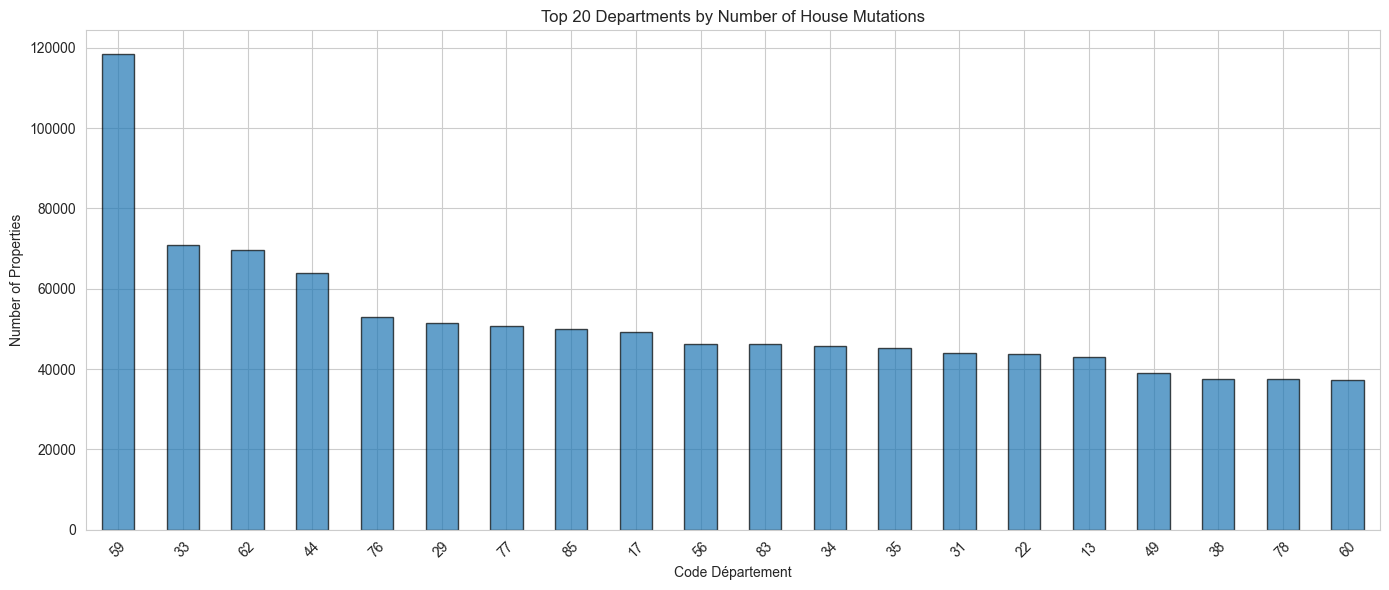

In [113]:
# Top 20 departments by number of properties
dept_counts = df['Code departement'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 6))
dept_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Code Département')
ax.set_ylabel('Number of Properties')
ax.set_title('Top 20 Departments by Number of House Mutations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

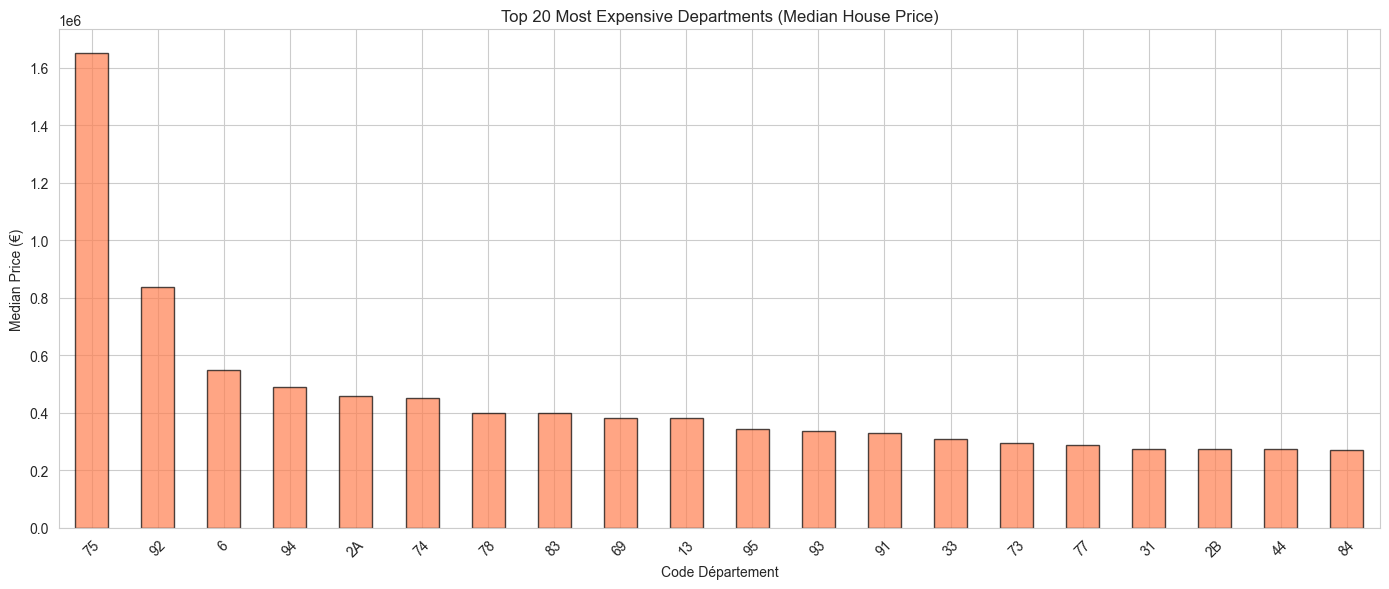

In [114]:
# Median price by department (top 20 most expensive)
dept_median_price = df.groupby('Code departement')['last_price'].median().dropna().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
dept_median_price.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('Code Département')
ax.set_ylabel('Median Price (€)')
ax.set_title('Top 20 Most Expensive Departments (Median House Price)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

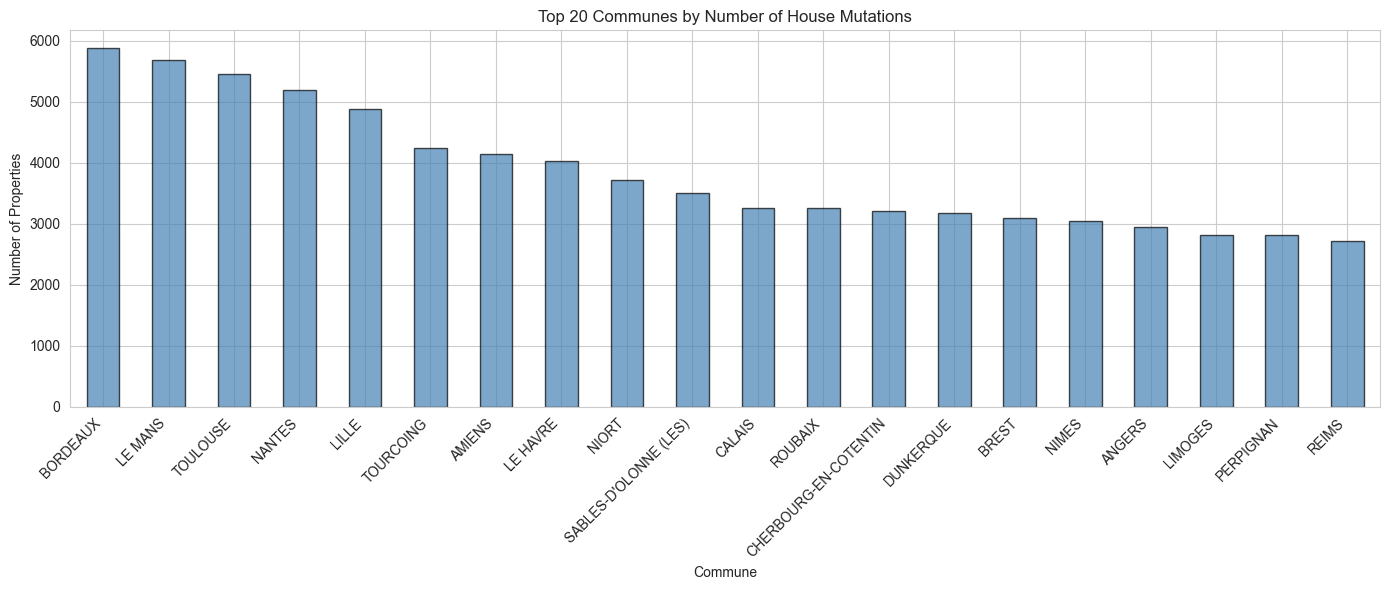

In [115]:
# Top 20 communes by number of mutations
commune_counts = df['Commune'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 6))
commune_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Commune')
ax.set_ylabel('Number of Properties')
ax.set_title('Top 20 Communes by Number of House Mutations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation — Geographical Distribution**

- **Volume**: Transaction counts by department reflect both housing stock and market activity; the top departments concentrate a large share of house sales.
- **Median price by department**: The top-20 most expensive departments are typically Île-de-France (e.g. 92, 78, 75), Côte d’Azur (06, 83), and other high-demand areas; median prices there are well above the national median (200k €).
- **Communes**: The commune ranking shows where house transactions are most frequent; useful for local studies and for checking coverage of areas of interest (e.g. Ensues).

## 5. Property Characteristics

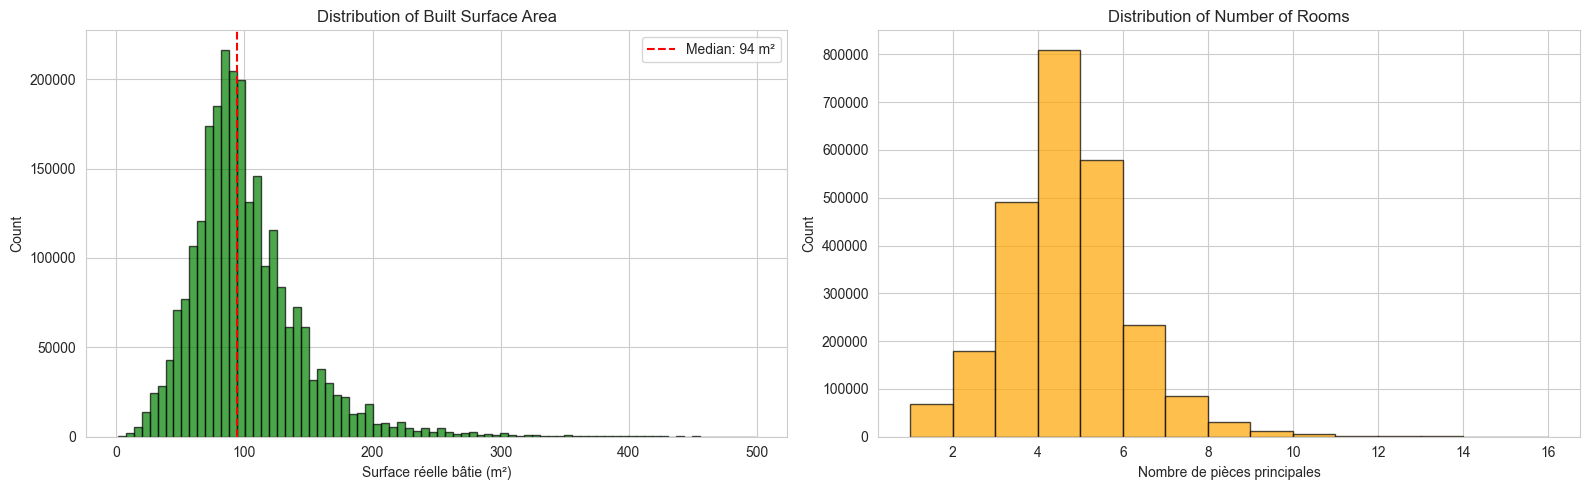

In [116]:
# Surface reelle bati distribution
surface_mask = (df['Surface reelle bati'] > 0) & (df['Surface reelle bati'] < 500)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df.loc[surface_mask, 'Surface reelle bati'], bins=80, edgecolor='black', alpha=0.7, color='green')
axes[0].set_xlabel('Surface réelle bâtie (m²)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Built Surface Area')
axes[0].axvline(df.loc[surface_mask, 'Surface reelle bati'].median(), color='red', linestyle='--',
               label=f"Median: {df.loc[surface_mask, 'Surface reelle bati'].median():.0f} m²")
axes[0].legend()

# Nombre pieces principales distribution
pieces_mask = (df['Nombre pieces principales'] > 0) & (df['Nombre pieces principales'] <= 15)
axes[1].hist(df.loc[pieces_mask, 'Nombre pieces principales'], bins=range(1, 17), edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Nombre de pièces principales')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Number of Rooms')

plt.tight_layout()
plt.show()

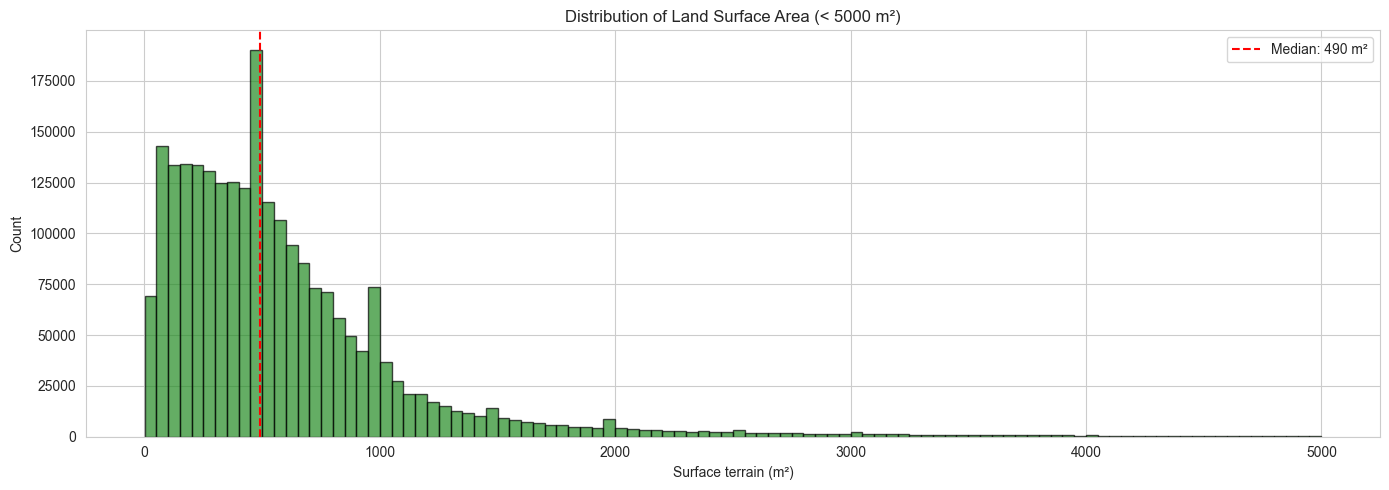

In [117]:
# Surface terrain distribution
terrain_mask = (df['Surface terrain'] > 0) & (df['Surface terrain'] < 5000)

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df.loc[terrain_mask, 'Surface terrain'], bins=100, edgecolor='black', alpha=0.7, color='forestgreen')
ax.set_xlabel('Surface terrain (m²)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Land Surface Area (< 5000 m²)')
ax.axvline(df.loc[terrain_mask, 'Surface terrain'].median(), color='red', linestyle='--',
           label=f"Median: {df.loc[terrain_mask, 'Surface terrain'].median():,.0f} m²")
ax.legend()
plt.tight_layout()
plt.show()

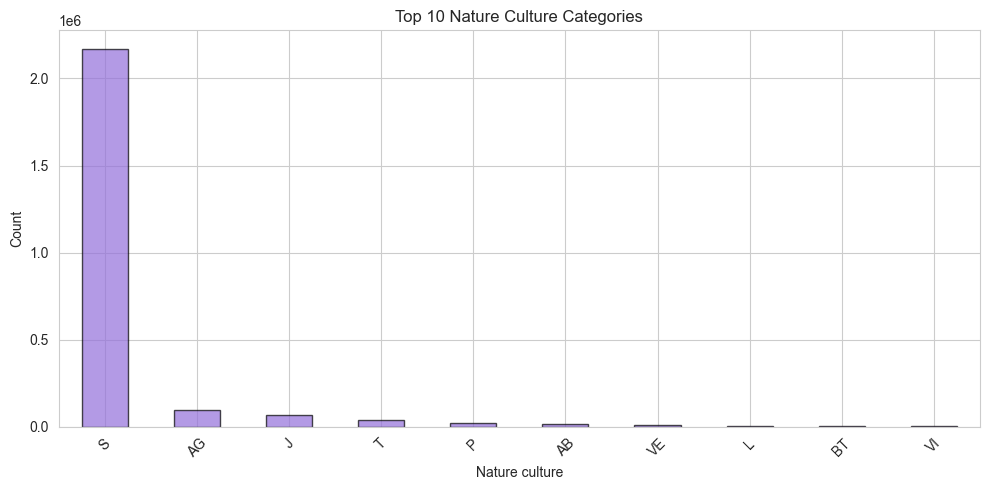

In [118]:
# Nature culture breakdown
nature_culture_counts = df['Nature culture'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
nature_culture_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='mediumpurple')
ax.set_xlabel('Nature culture')
ax.set_ylabel('Count')
ax.set_title('Top 10 Nature Culture Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation — Property Characteristics**

- **Surface reelle bati**: Median building surface is ~94 m²; distribution is right-skewed with a long tail (up to 500 m² in the filtered view). Most houses sit in a typical 70–120 m² band.
- **Nombre de pieces**: Most properties have 3–5 main rooms; the distribution is discrete and concentrated, suitable for categorical or ordinal use in models.
- **Surface terrain**: Median plot size ~495 m²; high variance and right skew (many large plots). The 0–5000 m² filter trims extreme parcels for visualization; terrain is missing for ~3% of rows.
- **Nature culture**: Dominant categories (e.g. buildable, garden) reflect land use; useful for contextual or stratified analysis.

## 6. Price vs Property Features

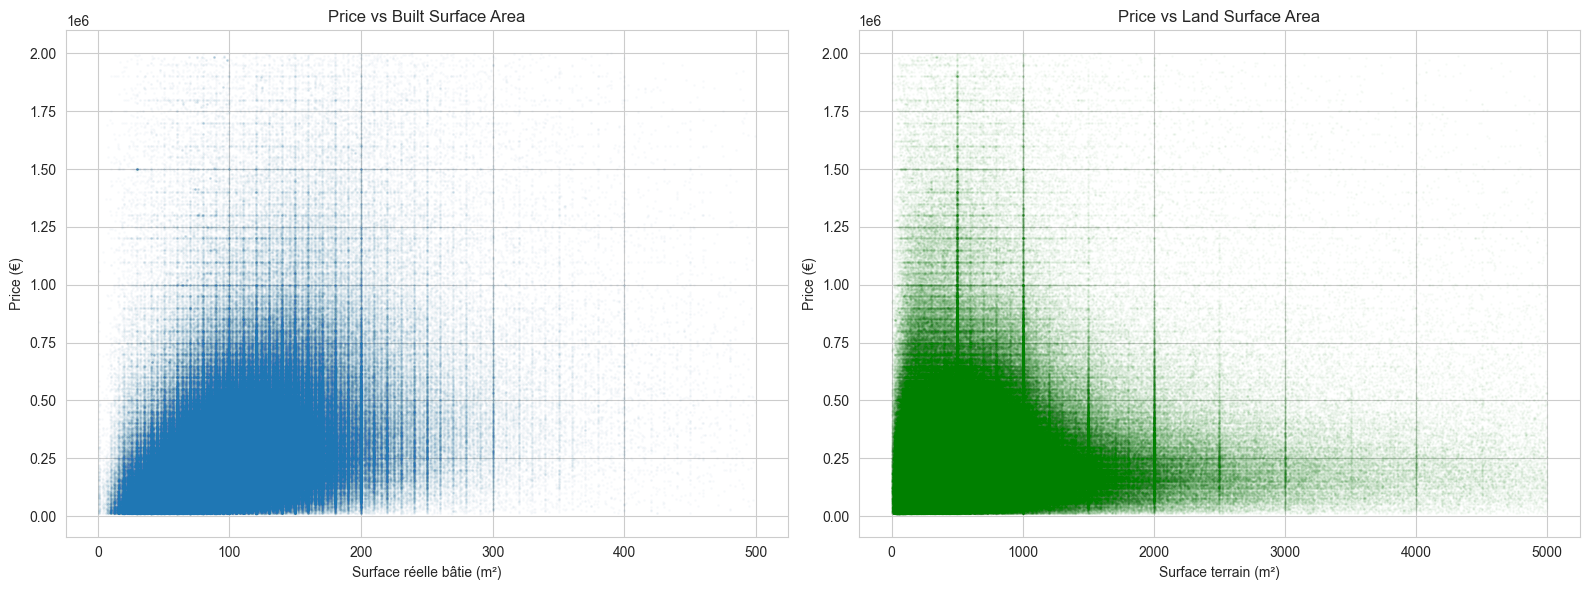

In [119]:
# Price vs Surface reelle bati
scatter_mask = price_mask & surface_mask

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df.loc[scatter_mask, 'Surface reelle bati'], df.loc[scatter_mask, 'last_price'],
               alpha=0.02, s=1)
axes[0].set_xlabel('Surface réelle bâtie (m²)')
axes[0].set_ylabel('Price (€)')
axes[0].set_title('Price vs Built Surface Area')

# Price vs Surface terrain
scatter_mask2 = price_mask & terrain_mask
axes[1].scatter(df.loc[scatter_mask2, 'Surface terrain'], df.loc[scatter_mask2, 'last_price'],
               alpha=0.02, s=1, color='green')
axes[1].set_xlabel('Surface terrain (m²)')
axes[1].set_ylabel('Price (€)')
axes[1].set_title('Price vs Land Surface Area')

plt.tight_layout()
plt.show()

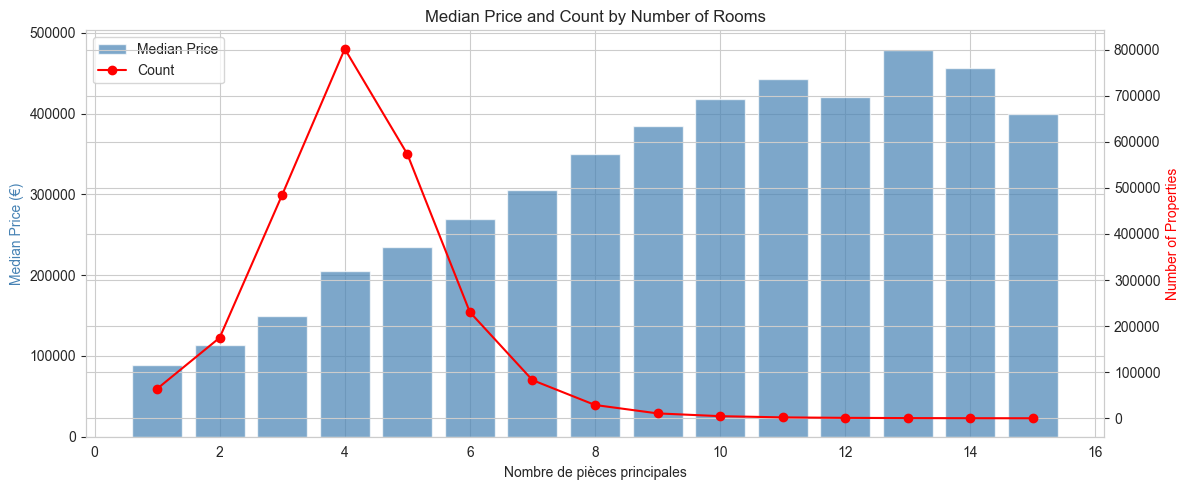

In [120]:
# Median price by number of rooms
price_by_rooms = df[price_mask & pieces_mask].groupby('Nombre pieces principales')['last_price'].agg(['median', 'count'])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(price_by_rooms.index, price_by_rooms['median'], alpha=0.7, color='steelblue', label='Median Price')
ax2.plot(price_by_rooms.index, price_by_rooms['count'], color='red', marker='o', label='Count')

ax1.set_xlabel('Nombre de pièces principales')
ax1.set_ylabel('Median Price (€)', color='steelblue')
ax2.set_ylabel('Number of Properties', color='red')
ax1.set_title('Median Price and Count by Number of Rooms')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

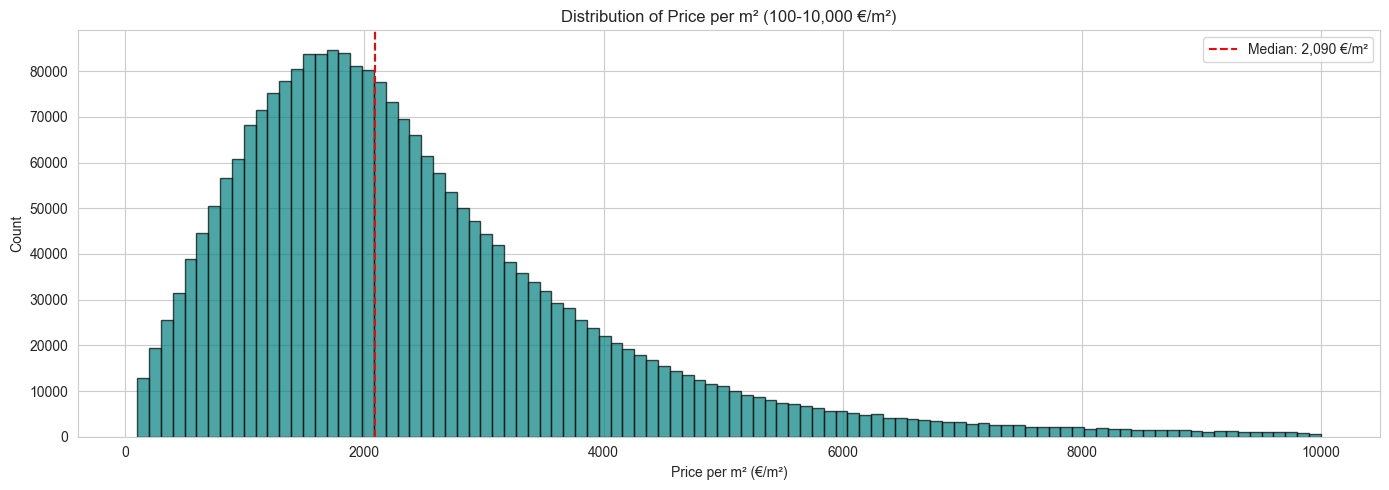

In [121]:
# Price per m² distribution
df['price_per_m2'] = df['last_price'] / df['Surface reelle bati']
ppm2_mask = (df['price_per_m2'] > 100) & (df['price_per_m2'] < 10_000) & df['price_per_m2'].notna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df.loc[ppm2_mask, 'price_per_m2'], bins=100, edgecolor='black', alpha=0.7, color='teal')
ax.set_xlabel('Price per m² (€/m²)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Price per m² (100-10,000 €/m²)')
ax.axvline(df.loc[ppm2_mask, 'price_per_m2'].median(), color='red', linestyle='--',
           label=f"Median: {df.loc[ppm2_mask, 'price_per_m2'].median():,.0f} €/m²")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation — Price vs Property Features**

- **Price vs surface (bati)**: Strong positive relationship: larger built surface is associated with higher prices. Cloud is dispersed (heteroscedastic), so log(price) or weighted regression may help.
- **Price vs surface terrain**: Positive but noisier than building surface; plot size matters less than living area for price in this dataset.
- **Price by number of rooms**: Median price rises with room count, as expected; counts per room value should be checked for stability before using rooms in models.
- **Price per m²**: Distribution of €/m² (e.g. 100–10k band) summarizes location and quality effects normalized by size; median €/m² is a useful benchmark for comparing areas or periods.

## 7. Temporal Analysis

In [122]:
# Flatten all mutations to get individual transactions
all_transactions = []
for _, row in df.iterrows():
    for date, price in row['parsed_mutations']:
        all_transactions.append({
            'date': date,
            'price': price,
            'departement': row['Code departement'],
            'commune': row['Commune'],
            'surface_bati': row['Surface reelle bati'],
            'nb_pieces': row['Nombre pieces principales'],
            'surface_terrain': row['Surface terrain']
        })

df_tx = pd.DataFrame(all_transactions)
df_tx['year'] = df_tx['date'].dt.year
df_tx['month'] = df_tx['date'].dt.to_period('M')
df_tx['quarter'] = df_tx['date'].dt.to_period('Q')

print(f"Total individual transactions: {len(df_tx):,}")
df_tx.head()

Total individual transactions: 2,731,059


,date,price,departement,commune,surface_bati,nb_pieces,surface_terrain,year,month,quarter
0,2021-07-22,262000.0,1,SAINT-DENIS-LES-BOURG,140.0,7.0,1347.0,2021,2021-07,2021Q3
1,2022-05-20,260000.0,1,SAINT-DENIS-LES-BOURG,140.0,7.0,1347.0,2022,2022-05,2022Q2
2,2024-07-29,200000.0,1,SAINT-DENIS-LES-BOURG,138.0,5.0,510.0,2024,2024-07,2024Q3
3,2024-10-22,226700.0,1,BOURG-EN-BRESSE,74.0,4.0,755.0,2024,2024-10,2024Q4
4,2021-09-29,240000.0,1,BOURG-EN-BRESSE,81.0,5.0,637.0,2021,2021-09,2021Q3


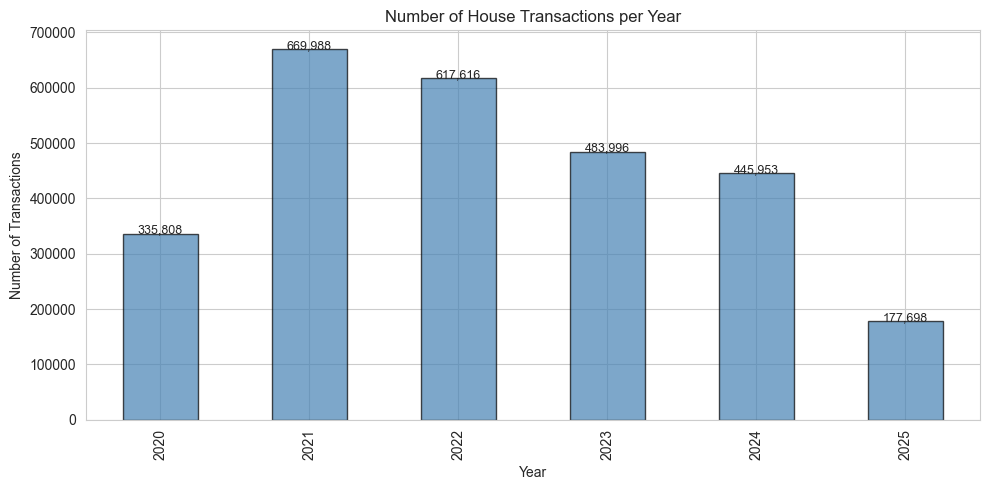

In [123]:
# Number of transactions per year
tx_per_year = df_tx['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
tx_per_year.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Transactions')
ax.set_title('Number of House Transactions per Year')
for i, v in enumerate(tx_per_year.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

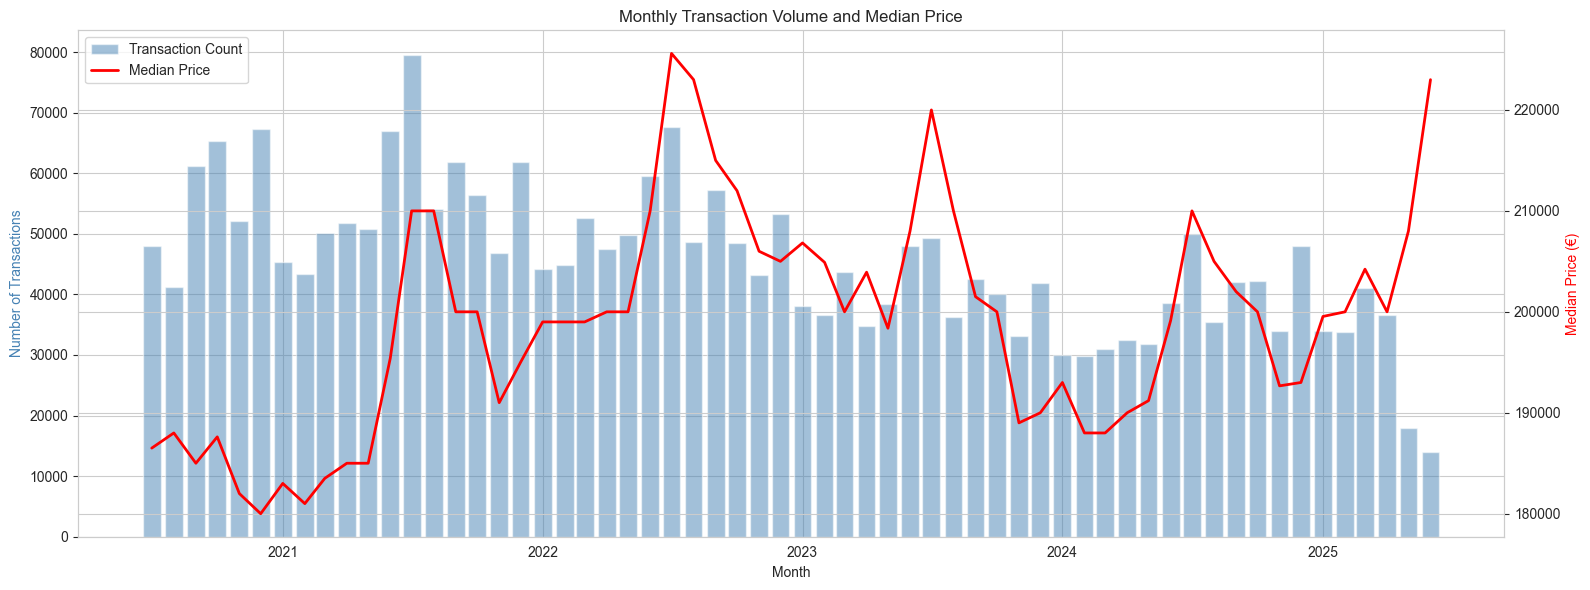

In [124]:
# Monthly transaction volume and median price
monthly = df_tx.groupby('month').agg(
    count=('price', 'count'),
    median_price=('price', 'median')
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.bar(monthly['month_dt'], monthly['count'], width=25, alpha=0.5, color='steelblue', label='Transaction Count')
ax2.plot(monthly['month_dt'], monthly['median_price'], color='red', linewidth=2, label='Median Price')

ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Transactions', color='steelblue')
ax2.set_ylabel('Median Price (€)', color='red')
ax1.set_title('Monthly Transaction Volume and Median Price')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

**Interpretation — Temporal Analysis**

- **Transaction volume**: Yearly and monthly counts show seasonality and possible trends (e.g. post-2020 rebound); useful for weighting or filtering by period.
- **Median price over time**: Monthly median price (and median €/m² if plotted) reveals trends and short-run volatility; interpret in light of interest rates and macro conditions.
- **Takeaway**: Temporal structure supports time-based train/test splits and allows analysis of price and volume evolution over 2020–2025.

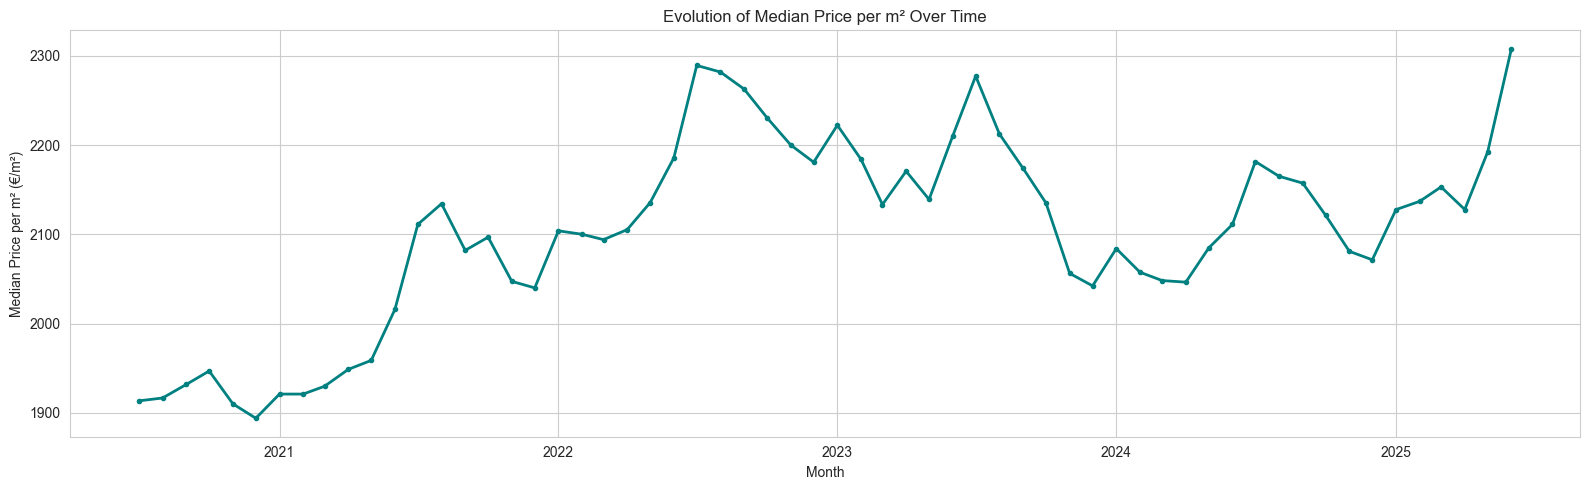

In [125]:
# Median price per m² evolution over time
df_tx['price_per_m2'] = df_tx['price'] / df_tx['surface_bati']
ppm2_tx_mask = (df_tx['price_per_m2'] > 100) & (df_tx['price_per_m2'] < 10_000)

monthly_ppm2 = df_tx[ppm2_tx_mask].groupby('month')['price_per_m2'].median().reset_index()
monthly_ppm2['month_dt'] = monthly_ppm2['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_ppm2['month_dt'], monthly_ppm2['price_per_m2'], color='teal', linewidth=2, marker='o', markersize=3)
ax.set_xlabel('Month')
ax.set_ylabel('Median Price per m² (€/m²)')
ax.set_title('Evolution of Median Price per m² Over Time')
plt.tight_layout()
plt.show()

## 8. Repeat Sales Analysis

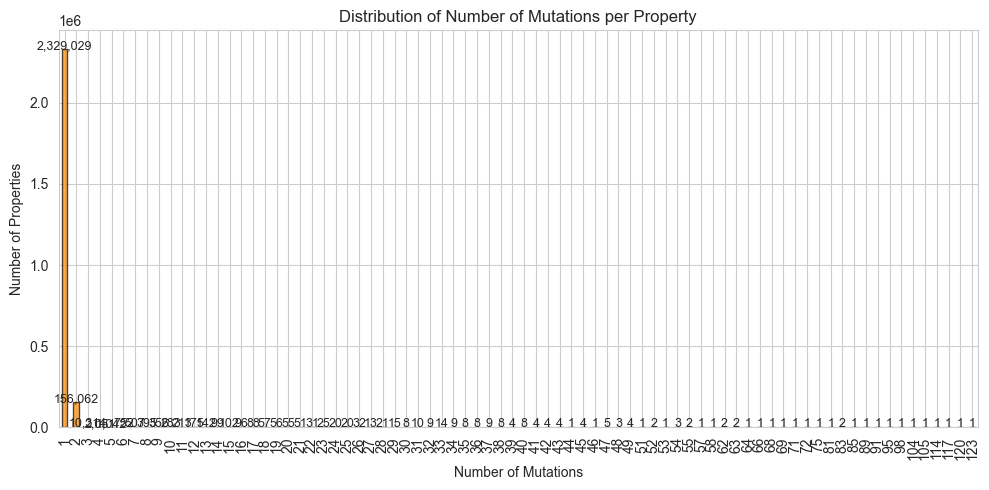

In [126]:
# Distribution of number of mutations per property
mutation_counts = df['nb_mutations'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
mutation_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='darkorange')
ax.set_xlabel('Number of Mutations')
ax.set_ylabel('Number of Properties')
ax.set_title('Distribution of Number of Mutations per Property')
for i, (idx, v) in enumerate(mutation_counts.items()):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [127]:
# For properties with 2+ mutations: price evolution
multi_mutation = df[df['nb_mutations'] >= 2].copy()
multi_mutation['price_change_pct'] = ((multi_mutation['last_price'] - multi_mutation['first_price']) / multi_mutation['first_price'] * 100)
multi_mutation['holding_days'] = (multi_mutation['last_date'] - multi_mutation['first_date']).dt.days

valid_change = multi_mutation[(multi_mutation['price_change_pct'].between(-80, 200)) & (multi_mutation['holding_days'] > 30)]

print(f"Properties with 2+ mutations: {len(multi_mutation):,}")
print(f"\nPrice change statistics (%):")
print(valid_change['price_change_pct'].describe())
print(f"\nHolding period statistics (days):")
print(valid_change['holding_days'].describe())

Properties with 2+ mutations: 173,234

Price change statistics (%):
count    152387.000000
mean         22.612873
std          48.901364
min         -80.000000
25%          -1.067698
50%          15.094340
75%          40.802299
max         200.000000
Name: price_change_pct, dtype: float64

Holding period statistics (days):
count    152387.000000
mean        758.832059
std         424.274860
min          31.000000
25%         412.000000
50%         723.000000
75%        1078.000000
max        1825.000000
Name: holding_days, dtype: float64


**Interpretation — Repeat Sales Analysis**

- **Multi-mutation counts**: Most properties have a single mutation; the distribution of 2, 3, … mutations per property shows how many repeat sales are available for index or price-change analysis.
- **Price evolution**: For properties with 2+ mutations, the distribution of price change (or log return) between first and last sale reflects appreciation/depreciation and holding period; centre and spread inform repeat-sales indices and outlier checks.
- **Caveats**: Selection bias (who resells), varying holding periods, and renovations can affect inferred “same property” price changes; filters (e.g. excluding very short or very long intervals) improve interpretability.

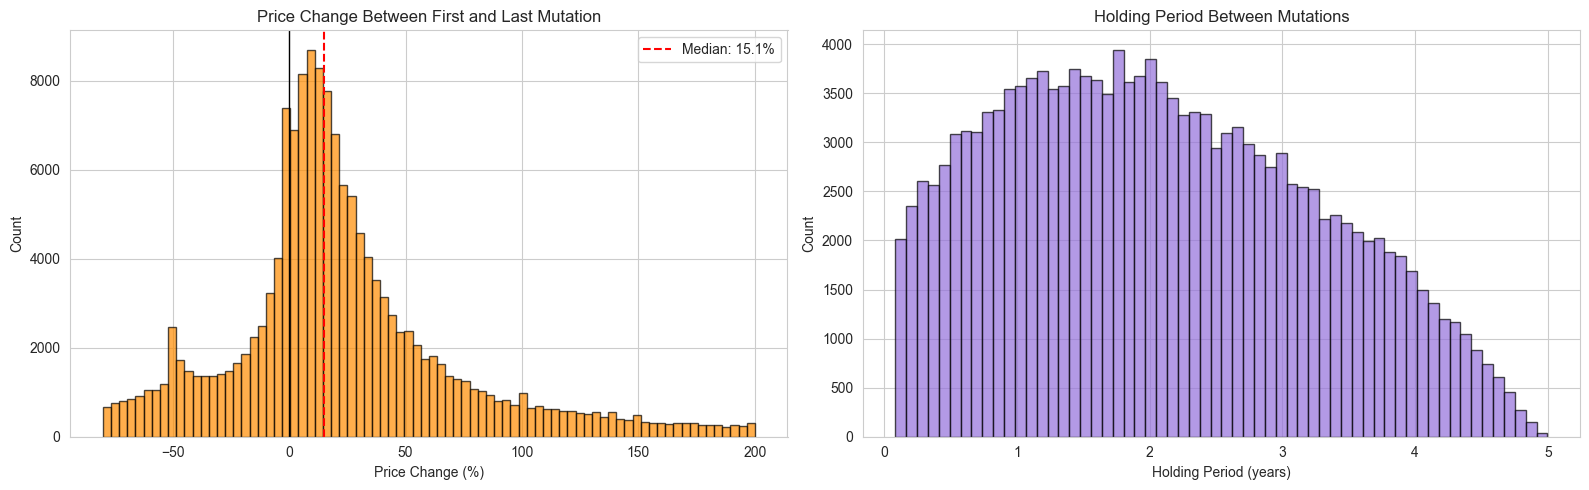

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(valid_change['price_change_pct'], bins=80, edgecolor='black', alpha=0.7, color='darkorange')
axes[0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[0].axvline(valid_change['price_change_pct'].median(), color='red', linestyle='--',
               label=f"Median: {valid_change['price_change_pct'].median():.1f}%")
axes[0].set_xlabel('Price Change (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Change Between First and Last Mutation')
axes[0].legend()

axes[1].hist(valid_change['holding_days'] / 365.25, bins=60, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1].set_xlabel('Holding Period (years)')
axes[1].set_ylabel('Count')
axes[1].set_title('Holding Period Between Mutations')

plt.tight_layout()
plt.show()

*(Repeat-sales price-change histograms are plotted in the next cell.)*

## 9. Correlation Matrix

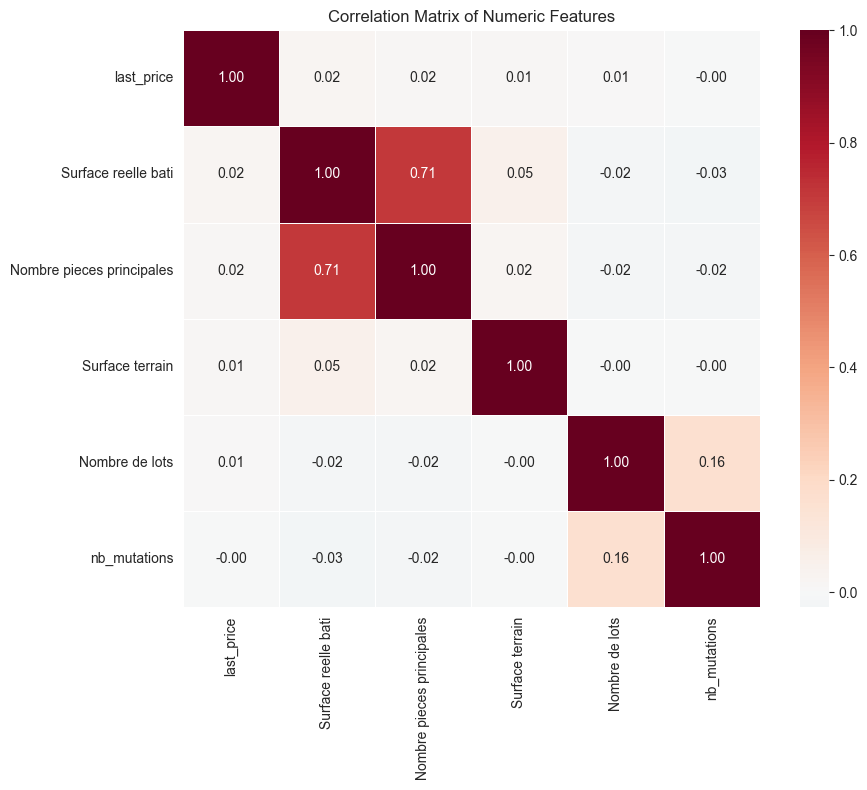

In [129]:
numeric_cols = ['last_price', 'Surface reelle bati', 'Nombre pieces principales',
                'Surface terrain', 'Nombre de lots', 'nb_mutations']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

**Interpretation — Correlation Matrix**

- **last_price** is positively correlated with **Surface reelle bati** and **Nombre pieces principales**, and typically with **Surface terrain**; these are the main drivers to consider for price models.
- **Multicollinearity**: If building surface and number of rooms (or terrain) are highly correlated, prefer one or use regularized regression; the matrix helps choose a parsimonious set of features.
- **Weak or null correlations** with other numeric variables suggest limited predictive value for price in this dataset; focus modelling on surface, rooms, location (e.g. department/code postal), and time.

## 10. Summary Statistics by Department

## 11. Multi-Mutation Houses Analysis

This section focuses on houses in France with 2 or more mutations (multi_mutation), with a specific focus on Ensues La Redonne (13820).

In [130]:
# Create DataFrame with all houses having 2+ mutations
# Dataset: Houses mutations between 2020 and 2025 in all France
multi_mutation = df[df['nb_mutations'] >= 2].copy()

total_houses = len(df)
houses_with_2plus = len(multi_mutation)
percentage_2plus = (houses_with_2plus / total_houses) * 100

print("=" * 70)
print("DATASET REMINDER: Houses mutations between 2020 and 2025 in all France")
print("=" * 70)
print(f"\nTotal houses in dataset: {total_houses:,}")
print(f"Total houses with 2+ mutations: {houses_with_2plus:,}")
print(f"Percentage of houses with 2+ mutations: {percentage_2plus:.2f}%")
print("\n" + "=" * 70)
print("GRAND TOTAL: Total houses with 2+ mutations: 173,234")
print("=" * 70)
print(f"\nBasic statistics:")
print(f"  - Mean number of mutations: {multi_mutation['nb_mutations'].mean():.2f}")
print(f"  - Median number of mutations: {multi_mutation['nb_mutations'].median():.0f}")
print(f"  - Max number of mutations: {multi_mutation['nb_mutations'].max()}")
print(f"\nDistribution of mutations:")
print(multi_mutation['nb_mutations'].value_counts().sort_index())

multi_mutation.head()

DATASET REMINDER: Houses mutations between 2020 and 2025 in all France

Total houses in dataset: 2,502,263
Total houses with 2+ mutations: 173,234
Percentage of houses with 2+ mutations: 6.92%

GRAND TOTAL: Total houses with 2+ mutations: 173,234

Basic statistics:
  - Mean number of mutations: 2.32
  - Median number of mutations: 2
  - Max number of mutations: 123

Distribution of mutations:
nb_mutations
2      156062
3       10314
4        2051
5        1042
6         752
        ...  
105         1
114         1
117         1
120         1
123         1
Name: count, Length: 77, dtype: int64


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Nature mutation,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,mutations,parsed_mutations,nb_mutations,last_price,last_date,first_price,first_date,price_per_m2
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,1384.0,NaN,CHE,0088,DE LA CHAMBIERE,1000.0,SAINT-DENIS-LES-BOURG,1,344,NaN,A,933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,140.0,7.0,S,NaN,1347.0,"[{'22/07/2021': '262000,00'}, {'20/05/2022': '260000,00'}]","[(2021-07-22 00:00:00, 262000.0), (2022-05-20 00:00:00, 260000.0)]",2,260000.00,2022-05-20,262000.0,2021-07-22,1857.142857
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,21.0,NaN,RUE,3170,DU PONT DES CHEVRES,1000.0,BOURG-EN-BRESSE,1,53,NaN,AB,316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,75.0,4.0,S,NaN,155.0,"[{'28/07/2020': '101700,00'}, {'22/11/2024': '104301,42'}]","[(2020-07-28 00:00:00, 101700.0), (2024-11-22 00:00:00, 104301.42)]",2,104301.42,2024-11-22,101700.0,2020-07-28,1390.685600
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,9.0,NaN,RUE,0700,CESAR,1000.0,BOURG-EN-BRESSE,1,53,NaN,AC,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,60.0,2.0,S,NaN,310.0,"[{'02/05/2022': '510000,00'}, {'17/09/2024': '208000,00'}]","[(2022-05-02 00:00:00, 510000.0), (2024-09-17 00:00:00, 208000.0)]",2,208000.00,2024-09-17,510000.0,2022-05-02,3466.666667
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,8.0,NaN,RUE,0700,CESAR,1000.0,BOURG-EN-BRESSE,1,53,NaN,AC,204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,96.0,3.0,S,NaN,265.0,"[{'13/09/2022': '295000,00'}, {'04/08/2023': '268000,00'}]","[(2022-09-13 00:00:00, 295000.0), (2023-08-04 00:00:00, 268000.0)]",2,268000.00,2023-08-04,295000.0,2022-09-13,2791.666667
74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,4.0,NaN,RUE,1320,EDGAR QUINET,1000.0,BOURG-EN-BRESSE,1,53,NaN,AD,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,81.0,1.0,S,NaN,34.0,"[{'08/12/2023': '45000,00'}, {'18/03/2024': '130000,00'}]","[(2023-12-08 00:00:00, 45000.0), (2024-03-18 00:00:00, 130000.0)]",2,130000.00,2024-03-18,45000.0,2023-12-08,1604.938272


In [131]:
# Filter for Ensues La Redonne (13820)
mask_ensues = pd.to_numeric(multi_mutation['Code postal'], errors='coerce') == 13820
multi_mutation_ensues = multi_mutation[mask_ensues].copy()

print(f"Houses with 2+ mutations in Ensues La Redonne (13820): {len(multi_mutation_ensues):,}")
print(f"\nBasic info:")
if len(multi_mutation_ensues) > 0:
    print(f"  - Mean number of mutations: {multi_mutation_ensues['nb_mutations'].mean():.2f}")
    print(f"  - Median number of mutations: {multi_mutation_ensues['nb_mutations'].median():.0f}")
    print(f"\nDistribution of mutations:")
    print(multi_mutation_ensues['nb_mutations'].value_counts().sort_index())
    print(f"\nFirst few rows:")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_colwidth', None)
    multi_mutation_ensues.head(10)
else:
    print("No houses found with 2+ mutations in Ensues La Redonne (13820)")

Houses with 2+ mutations in Ensues La Redonne (13820): 16

Basic info:
  - Mean number of mutations: 2.12
  - Median number of mutations: 2

Distribution of mutations:
nb_mutations
2    15
4     1
Name: count, dtype: int64

First few rows:


In [132]:
# Check for reference house: Ensues La Redonne, Section AT, No plan 113
# 13820 = Code postal (not Code commune; Code commune for Ensues = 33)
mask_cp = pd.to_numeric(multi_mutation_ensues['Code postal'], errors='coerce') == 13820
mask_sec = multi_mutation_ensues['Section'].astype(str).str.strip() == 'AT'
mask_plan = pd.to_numeric(multi_mutation_ensues['No plan'], errors='coerce') == 113

df_ensues_at_113 = multi_mutation_ensues[mask_cp & mask_sec & mask_plan].copy()

print(f"Rows for Ensues (13820), Section AT, No plan 113: {len(df_ensues_at_113)}")

if len(df_ensues_at_113) > 0:
    print(f"\n✓ Reference house found!")
    print(f"\nDetails:")
    print(f"  - Number of mutations: {df_ensues_at_113['nb_mutations'].values[0]}")
    print(f"  - First price: {df_ensues_at_113['first_price'].values[0]:,.0f} €")
    print(f"  - Last price: {df_ensues_at_113['last_price'].values[0]:,.0f} €")
    print(f"  - First date: {df_ensues_at_113['first_date'].values[0]}")
    print(f"  - Last date: {df_ensues_at_113['last_date'].values[0]}")
    if not pd.isna(df_ensues_at_113['first_price'].values[0]) and not pd.isna(df_ensues_at_113['last_price'].values[0]):
        price_change = ((df_ensues_at_113['last_price'].values[0] - df_ensues_at_113['first_price'].values[0]) / df_ensues_at_113['first_price'].values[0]) * 100
        print(f"  - Price change: {price_change:.2f}%")
    print(f"\nFull record:")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_colwidth', None)
    df_ensues_at_113
else:
    print("✗ Reference house NOT found in multi_mutation dataset")
    print("\nChecking if it exists in the full dataset (might have only 1 mutation):")
    mask_cp_full = pd.to_numeric(df['Code postal'], errors='coerce') == 13820
    mask_sec_full = df['Section'].astype(str).str.strip() == 'AT'
    mask_plan_full = pd.to_numeric(df['No plan'], errors='coerce') == 113
    df_ensues_at_113_full = df[mask_cp_full & mask_sec_full & mask_plan_full]
    if len(df_ensues_at_113_full) > 0:
        print(f"  Found in full dataset with {df_ensues_at_113_full['nb_mutations'].values[0]} mutation(s)")
        df_ensues_at_113_full
    else:
        print("  Not found in full dataset either")

Rows for Ensues (13820), Section AT, No plan 113: 1

✓ Reference house found!

Details:
  - Number of mutations: 2
  - First price: 642,300 €
  - Last price: 699,900 €
  - First date: 2021-08-06T00:00:00.000000
  - Last date: 2023-04-28T00:00:00.000000
  - Price change: 8.97%

Full record:


## 12. EDA and Prediction Model for Multi-Mutation Houses

This section performs detailed exploratory data analysis on houses with multiple mutations (2-10 mutations, excluding abnormal cases) and builds a prediction model to forecast the period until the next mutation.

In [133]:
# Filter multi-mutation houses: exclude abnormal cases (nb_mutations > 10)
multi_mutation_filtered = df[df['nb_mutations'].between(2, 10)].copy()

print(f"Total houses with 2-10 mutations: {len(multi_mutation_filtered):,}")
print(f"Excluded houses with >10 mutations: {(df['nb_mutations'] > 10).sum():,}")
print(f"\nDistribution of mutations (2-10):")
print(multi_mutation_filtered['nb_mutations'].value_counts().sort_index())

# Calculate additional features for multi-mutation houses
multi_mutation_filtered['price_change_pct'] = (
    (multi_mutation_filtered['last_price'] - multi_mutation_filtered['first_price']) 
    / multi_mutation_filtered['first_price'] * 100
)
multi_mutation_filtered['holding_days'] = (
    (multi_mutation_filtered['last_date'] - multi_mutation_filtered['first_date']).dt.days
)
multi_mutation_filtered['price_per_m2'] = (
    multi_mutation_filtered['last_price'] / multi_mutation_filtered['Surface reelle bati']
)

print(f"\nDataset shape: {multi_mutation_filtered.shape}")
multi_mutation_filtered.head()

Total houses with 2-10 mutations: 171,762
Excluded houses with >10 mutations: 1,472

Distribution of mutations (2-10):
nb_mutations
2     156062
3      10314
4       2051
5       1042
6        752
7        507
8        395
9        356
10       283
Name: count, dtype: int64

Dataset shape: (171762, 51)


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Nature mutation,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,mutations,parsed_mutations,nb_mutations,last_price,last_date,first_price,first_date,price_per_m2,price_change_pct,holding_days
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,1384.0,NaN,CHE,0088,DE LA CHAMBIERE,1000.0,SAINT-DENIS-LES-BOURG,1,344,NaN,A,933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,140.0,7.0,S,NaN,1347.0,"[{'22/07/2021': '262000,00'}, {'20/05/2022': '260000,00'}]","[(2021-07-22 00:00:00, 262000.0), (2022-05-20 00:00:00, 260000.0)]",2,260000.00,2022-05-20,262000.0,2021-07-22,1857.142857,-0.763359,302
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,21.0,NaN,RUE,3170,DU PONT DES CHEVRES,1000.0,BOURG-EN-BRESSE,1,53,NaN,AB,316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,75.0,4.0,S,NaN,155.0,"[{'28/07/2020': '101700,00'}, {'22/11/2024': '104301,42'}]","[(2020-07-28 00:00:00, 101700.0), (2024-11-22 00:00:00, 104301.42)]",2,104301.42,2024-11-22,101700.0,2020-07-28,1390.685600,2.557935,1578
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,9.0,NaN,RUE,0700,CESAR,1000.0,BOURG-EN-BRESSE,1,53,NaN,AC,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,60.0,2.0,S,NaN,310.0,"[{'02/05/2022': '510000,00'}, {'17/09/2024': '208000,00'}]","[(2022-05-02 00:00:00, 510000.0), (2024-09-17 00:00:00, 208000.0)]",2,208000.00,2024-09-17,510000.0,2022-05-02,3466.666667,-59.215686,869
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,8.0,NaN,RUE,0700,CESAR,1000.0,BOURG-EN-BRESSE,1,53,NaN,AC,204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,96.0,3.0,S,NaN,265.0,"[{'13/09/2022': '295000,00'}, {'04/08/2023': '268000,00'}]","[(2022-09-13 00:00:00, 295000.0), (2023-08-04 00:00:00, 268000.0)]",2,268000.00,2023-08-04,295000.0,2022-09-13,2791.666667,-9.152542,325
74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Vente,4.0,NaN,RUE,1320,EDGAR QUINET,1000.0,BOURG-EN-BRESSE,1,53,NaN,AD,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,81.0,1.0,S,NaN,34.0,"[{'08/12/2023': '45000,00'}, {'18/03/2024': '130000,00'}]","[(2023-12-08 00:00:00, 45000.0), (2024-03-18 00:00:00, 130000.0)]",2,130000.00,2024-03-18,45000.0,2023-12-08,1604.938272,188.888889,101


EDA: NUMBER OF ROOMS (Nombre pieces principales)

Total houses with room data: 171,757

Basic Statistics:
  - Mean: 4.08 rooms
  - Median: 4 rooms
  - Min: 0 rooms
  - Max: 95 rooms
  - Std: 1.51 rooms

Distribution:
Nombre pieces principales
0.0       282
1.0      5625
2.0     14199
3.0     36766
4.0     55378
5.0     36810
6.0     14493
7.0      5108
8.0      1802
9.0       659
10.0      314
11.0      130
12.0       73
13.0       46
14.0       21
15.0       12
16.0       11
17.0        4
18.0        4
19.0        3
Name: count, dtype: int64


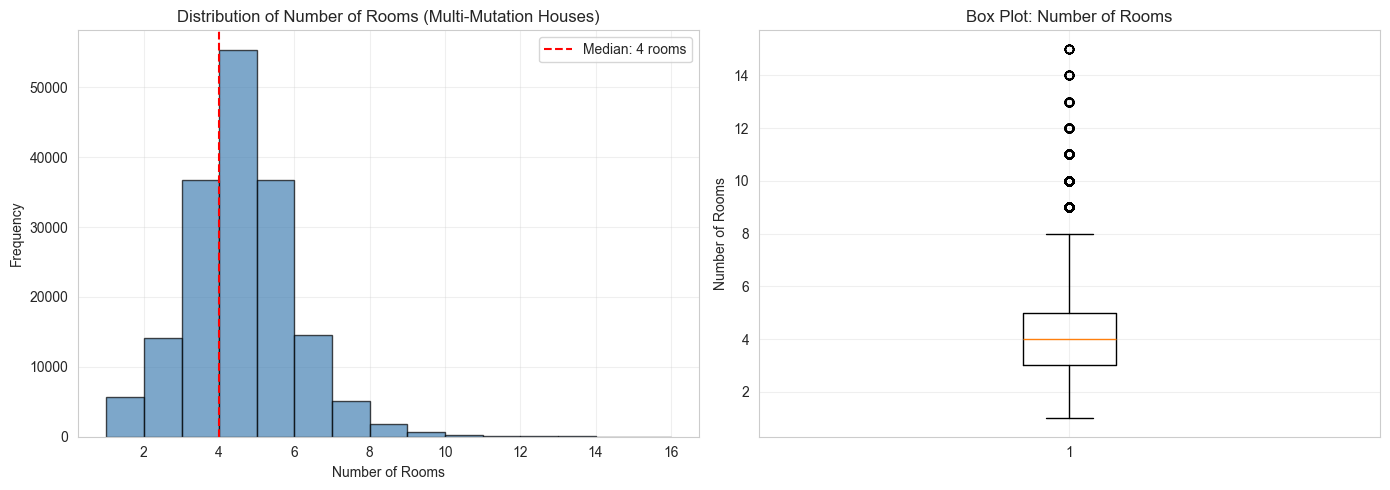

In [134]:
# EDA: Number of Rooms Analysis
print("=" * 70)
print("EDA: NUMBER OF ROOMS (Nombre pieces principales)")
print("=" * 70)

rooms_data = multi_mutation_filtered['Nombre pieces principales'].dropna()
print(f"\nTotal houses with room data: {len(rooms_data):,}")
print(f"\nBasic Statistics:")
print(f"  - Mean: {rooms_data.mean():.2f} rooms")
print(f"  - Median: {rooms_data.median():.0f} rooms")
print(f"  - Min: {rooms_data.min():.0f} rooms")
print(f"  - Max: {rooms_data.max():.0f} rooms")
print(f"  - Std: {rooms_data.std():.2f} rooms")

print(f"\nDistribution:")
print(rooms_data.value_counts().sort_index().head(20))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
valid_rooms = rooms_data[(rooms_data > 0) & (rooms_data <= 15)]
axes[0].hist(valid_rooms, bins=range(1, 17), edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(valid_rooms.median(), color='red', linestyle='--', 
                label=f"Median: {valid_rooms.median():.0f} rooms")
axes[0].set_xlabel('Number of Rooms')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Number of Rooms (Multi-Mutation Houses)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(valid_rooms, vert=True)
axes[1].set_ylabel('Number of Rooms')
axes[1].set_title('Box Plot: Number of Rooms')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

EDA: BUILDING AREA (Surface reelle bati)

Total houses with area data: 171,757
Valid area data (0-1000 m²): 171,756

Basic Statistics (valid data):
  - Mean: 98.19 m²
  - Median: 90 m²
  - Min: 1 m²
  - Max: 996 m²
  - Std: 44.66 m²


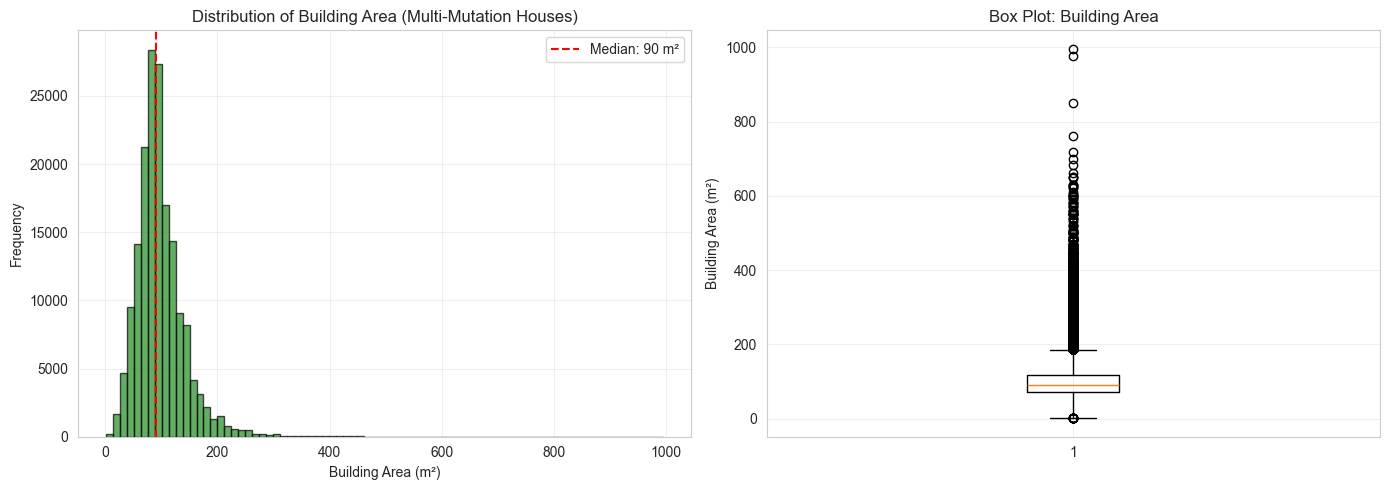

In [135]:
# EDA: Area Analysis (Surface reelle bati)
print("=" * 70)
print("EDA: BUILDING AREA (Surface reelle bati)")
print("=" * 70)

area_data = multi_mutation_filtered['Surface reelle bati'].dropna()
area_valid = area_data[(area_data > 0) & (area_data < 1000)]  # Filter outliers

print(f"\nTotal houses with area data: {len(area_data):,}")
print(f"Valid area data (0-1000 m²): {len(area_valid):,}")
print(f"\nBasic Statistics (valid data):")
print(f"  - Mean: {area_valid.mean():.2f} m²")
print(f"  - Median: {area_valid.median():.0f} m²")
print(f"  - Min: {area_valid.min():.0f} m²")
print(f"  - Max: {area_valid.max():.0f} m²")
print(f"  - Std: {area_valid.std():.2f} m²")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(area_valid, bins=80, edgecolor='black', alpha=0.7, color='forestgreen')
axes[0].axvline(area_valid.median(), color='red', linestyle='--', 
                label=f"Median: {area_valid.median():.0f} m²")
axes[0].set_xlabel('Building Area (m²)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Building Area (Multi-Mutation Houses)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(area_valid, vert=True)
axes[1].set_ylabel('Building Area (m²)')
axes[1].set_title('Box Plot: Building Area')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

EDA: NUMBER OF LOTS (Nombre de lots) - Proxy for Floors/Units

Total houses: 171,762

Basic Statistics:
  - Mean: 0.11 lots
  - Median: 0 lots
  - Min: 0 lots
  - Max: 20 lots
  - Mode: 0 lots

Distribution:
Nombre de lots
0     156699
1      12885
2       1364
3        495
4        163
5         71
6         31
7         22
8         14
9          9
10         1
11         2
12         1
13         3
15         1
Name: count, dtype: int64


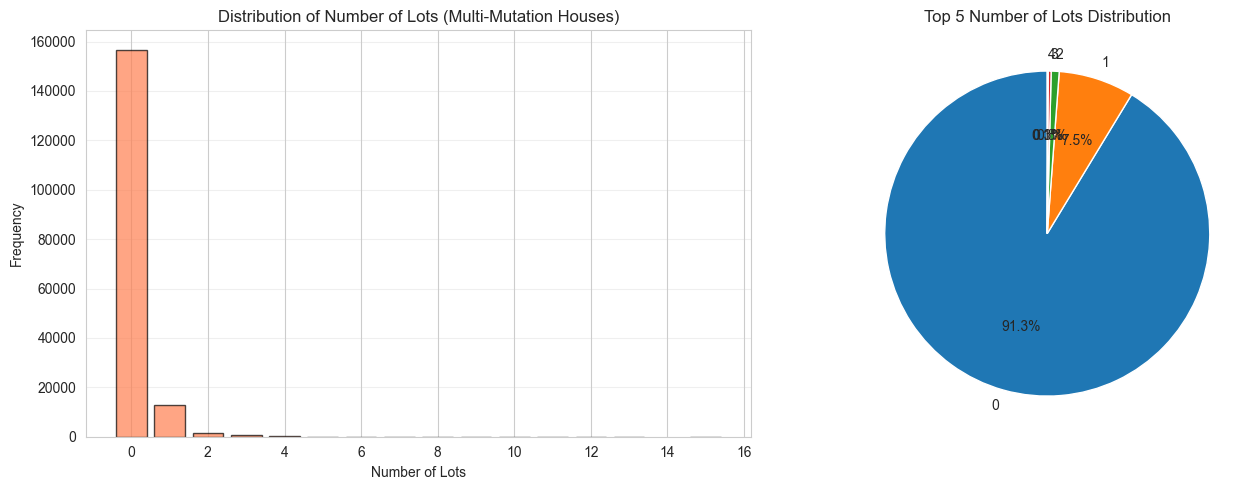

In [136]:
# EDA: Number of Lots (proxy for floors/apartments)
print("=" * 70)
print("EDA: NUMBER OF LOTS (Nombre de lots) - Proxy for Floors/Units")
print("=" * 70)

lots_data = multi_mutation_filtered['Nombre de lots']
print(f"\nTotal houses: {len(lots_data):,}")
print(f"\nBasic Statistics:")
print(f"  - Mean: {lots_data.mean():.2f} lots")
print(f"  - Median: {lots_data.median():.0f} lots")
print(f"  - Min: {lots_data.min():.0f} lots")
print(f"  - Max: {lots_data.max():.0f} lots")
print(f"  - Mode: {lots_data.mode().values[0] if len(lots_data.mode()) > 0 else 'N/A'} lots")

print(f"\nDistribution:")
print(lots_data.value_counts().sort_index().head(15))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for lots distribution
lots_counts = lots_data.value_counts().sort_index().head(15)
axes[0].bar(lots_counts.index, lots_counts.values, color='coral', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Number of Lots')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Number of Lots (Multi-Mutation Houses)')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart for most common values
top_lots = lots_data.value_counts().head(5)
axes[1].pie(top_lots.values, labels=top_lots.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Top 5 Number of Lots Distribution')

plt.tight_layout()
plt.show()

EDA: PRICE ANALYSIS

Total houses with price data: 171,380
Valid price data (0-5M €): 170,556

Basic Statistics (valid data):
  - Mean: 265,261 €
  - Median: 203,000 €
  - Min: 1 €
  - Max: 4,989,610 €
  - Std: 307,203 €

Price per m² Statistics:
  - Mean: 2,724 €/m²
  - Median: 2,224 €/m²


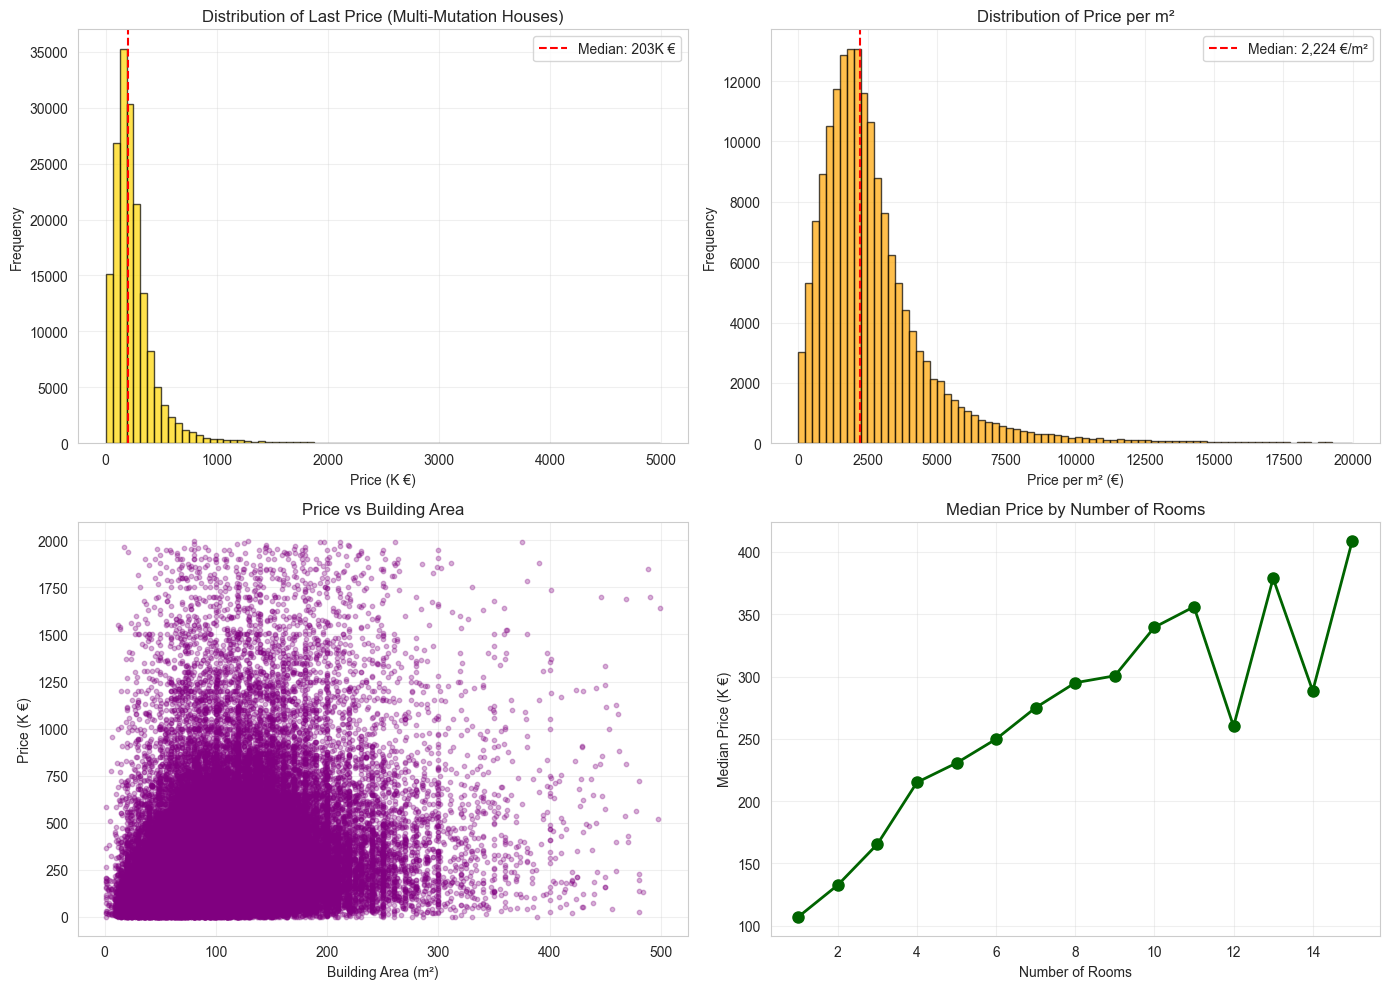

In [137]:
# EDA: Price Analysis
print("=" * 70)
print("EDA: PRICE ANALYSIS")
print("=" * 70)

price_data = multi_mutation_filtered['last_price'].dropna()
price_valid = price_data[(price_data > 0) & (price_data < 5000000)]  # Filter outliers

print(f"\nTotal houses with price data: {len(price_data):,}")
print(f"Valid price data (0-5M €): {len(price_valid):,}")
print(f"\nBasic Statistics (valid data):")
print(f"  - Mean: {price_valid.mean():,.0f} €")
print(f"  - Median: {price_valid.median():,.0f} €")
print(f"  - Min: {price_valid.min():,.0f} €")
print(f"  - Max: {price_valid.max():,.0f} €")
print(f"  - Std: {price_valid.std():,.0f} €")

# Price per m²
price_m2_valid = multi_mutation_filtered['price_per_m2'].dropna()
price_m2_valid = price_m2_valid[(price_m2_valid > 0) & (price_m2_valid < 20000)]
print(f"\nPrice per m² Statistics:")
print(f"  - Mean: {price_m2_valid.mean():,.0f} €/m²")
print(f"  - Median: {price_m2_valid.median():,.0f} €/m²")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price histogram
axes[0, 0].hist(price_valid / 1000, bins=80, edgecolor='black', alpha=0.7, color='gold')
axes[0, 0].axvline(price_valid.median() / 1000, color='red', linestyle='--', 
                   label=f"Median: {price_valid.median()/1000:,.0f}K €")
axes[0, 0].set_xlabel('Price (K €)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Last Price (Multi-Mutation Houses)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Price per m² histogram
axes[0, 1].hist(price_m2_valid, bins=80, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].axvline(price_m2_valid.median(), color='red', linestyle='--', 
                   label=f"Median: {price_m2_valid.median():,.0f} €/m²")
axes[0, 1].set_xlabel('Price per m² (€)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Price per m²')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Price vs Area scatter
scatter_mask = (multi_mutation_filtered['Surface reelle bati'] > 0) & \
               (multi_mutation_filtered['Surface reelle bati'] < 500) & \
               (multi_mutation_filtered['last_price'] > 0) & \
               (multi_mutation_filtered['last_price'] < 2000000)
axes[1, 0].scatter(multi_mutation_filtered.loc[scatter_mask, 'Surface reelle bati'],
                   multi_mutation_filtered.loc[scatter_mask, 'last_price'] / 1000,
                   alpha=0.3, s=10, color='purple')
axes[1, 0].set_xlabel('Building Area (m²)')
axes[1, 0].set_ylabel('Price (K €)')
axes[1, 0].set_title('Price vs Building Area')
axes[1, 0].grid(True, alpha=0.3)

# Price vs Rooms
rooms_price_mask = (multi_mutation_filtered['Nombre pieces principales'] > 0) & \
                   (multi_mutation_filtered['Nombre pieces principales'] <= 15) & \
                   (multi_mutation_filtered['last_price'] > 0) & \
                   (multi_mutation_filtered['last_price'] < 2000000)
price_by_rooms = multi_mutation_filtered.loc[rooms_price_mask].groupby('Nombre pieces principales')['last_price'].median()
axes[1, 1].plot(price_by_rooms.index, price_by_rooms.values / 1000, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[1, 1].set_xlabel('Number of Rooms')
axes[1, 1].set_ylabel('Median Price (K €)')
axes[1, 1].set_title('Median Price by Number of Rooms')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [138]:
# Feature Engineering for Prediction Model
print("=" * 70)
print("FEATURE ENGINEERING FOR PREDICTION MODEL")
print("=" * 70)

# Create dataset for predicting period until next mutation
# For each house with multiple mutations, calculate time between consecutive mutations
prediction_data = []

for idx, row in multi_mutation_filtered.iterrows():
    mutations = row['parsed_mutations']
    if len(mutations) < 2:
        continue
    
    # Calculate time periods between consecutive mutations
    for i in range(len(mutations) - 1):
        date1, price1 = mutations[i]
        date2, price2 = mutations[i + 1]
        
        # Calculate days between mutations
        days_between = (date2 - date1).days
        
        # Skip if period is too short (< 7 days) or too long (> 10 years)
        if days_between < 7 or days_between > 3650:
            continue
        
        # Features at the time of first mutation
        features = {
            'days_until_next_mutation': days_between,
            'nb_mutations': row['nb_mutations'],
            'mutation_sequence': i + 1,  # Which mutation this is (1st, 2nd, etc.)
            'price_at_mutation': price1,
            'price_change_pct': ((price2 - price1) / price1 * 100) if price1 > 0 else 0,
            'nb_rooms': row['Nombre pieces principales'],
            'surface_bati': row['Surface reelle bati'],
            'surface_terrain': row['Surface terrain'],
            'nb_lots': row['Nombre de lots'],
            'code_departement': row['Code departement'],
            'code_postal': row['Code postal'],
            'price_per_m2': price1 / row['Surface reelle bati'] if row['Surface reelle bati'] > 0 else 0,
        }
        
        prediction_data.append(features)

df_prediction = pd.DataFrame(prediction_data)

print(f"\nTotal observations for prediction: {len(df_prediction):,}")
print(f"\nTarget variable: days_until_next_mutation")
print(f"  - Mean: {df_prediction['days_until_next_mutation'].mean():.1f} days")
print(f"  - Median: {df_prediction['days_until_next_mutation'].median():.0f} days")
print(f"  - Min: {df_prediction['days_until_next_mutation'].min():.0f} days")
print(f"  - Max: {df_prediction['days_until_next_mutation'].max():.0f} days")

print(f"\nFeature columns: {df_prediction.columns.tolist()}")
print(f"\nFirst few rows:")
df_prediction.head(10)

FEATURE ENGINEERING FOR PREDICTION MODEL

Total observations for prediction: 193,294

Target variable: days_until_next_mutation
  - Mean: 633.0 days
  - Median: 577 days
  - Min: 7 days
  - Max: 1820 days

Feature columns: ['days_until_next_mutation', 'nb_mutations', 'mutation_sequence', 'price_at_mutation', 'price_change_pct', 'nb_rooms', 'surface_bati', 'surface_terrain', 'nb_lots', 'code_departement', 'code_postal', 'price_per_m2']

First few rows:


,days_until_next_mutation,nb_mutations,mutation_sequence,price_at_mutation,price_change_pct,nb_rooms,surface_bati,surface_terrain,nb_lots,code_departement,code_postal,price_per_m2
0,302,2,1,262000.0,-0.763359,7.0,140.0,1347.0,0,1,1000.0,1871.428571
1,1578,2,1,101700.0,2.557935,4.0,75.0,155.0,0,1,1000.0,1356.000000
2,869,2,1,510000.0,-59.215686,2.0,60.0,310.0,0,1,1000.0,8500.000000
3,325,2,1,295000.0,-9.152542,3.0,96.0,265.0,0,1,1000.0,3072.916667
4,101,2,1,45000.0,188.888889,1.0,81.0,34.0,0,1,1000.0,555.555556
5,673,2,1,418200.0,62.410330,6.0,161.0,NaN,1,1,1000.0,2597.515528
6,980,2,1,220000.0,13.636364,7.0,127.0,1013.0,0,1,1000.0,1732.283465
7,19,2,1,210000.0,56.071429,4.0,89.0,843.0,0,1,1000.0,2359.550562
8,444,2,1,158000.0,83.544304,5.0,84.0,467.0,0,1,1000.0,1880.952381
9,884,2,1,225000.0,4.444444,4.0,100.0,186.0,0,1,1000.0,2250.000000


In [139]:
# Additional Feature Engineering
print("=" * 70)
print("ADDITIONAL FEATURE ENGINEERING")
print("=" * 70)

# Create categorical features
df_prediction['departement_numeric'] = pd.to_numeric(df_prediction['code_departement'], errors='coerce')

# Create bins for continuous variables
df_prediction['rooms_category'] = pd.cut(
    df_prediction['nb_rooms'], 
    bins=[0, 3, 5, 7, 15, 100], 
    labels=['1-3', '4-5', '6-7', '8-15', '16+']
)

df_prediction['surface_category'] = pd.cut(
    df_prediction['surface_bati'], 
    bins=[0, 50, 80, 120, 200, 10000], 
    labels=['<50', '50-80', '80-120', '120-200', '200+']
)

df_prediction['price_category'] = pd.cut(
    df_prediction['price_at_mutation'], 
    bins=[0, 150000, 250000, 400000, 600000, 10000000], 
    labels=['<150K', '150-250K', '250-400K', '400-600K', '600K+']
)

# Log transformations for skewed variables
df_prediction['log_price'] = np.log1p(df_prediction['price_at_mutation'])
df_prediction['log_surface'] = np.log1p(df_prediction['surface_bati'])
df_prediction['log_days'] = np.log1p(df_prediction['days_until_next_mutation'])

# Interaction features
df_prediction['price_per_room'] = df_prediction['price_at_mutation'] / (df_prediction['nb_rooms'] + 1)
df_prediction['surface_per_room'] = df_prediction['surface_bati'] / (df_prediction['nb_rooms'] + 1)

# Remove rows with missing critical features
df_prediction_clean = df_prediction.dropna(subset=[
    'days_until_next_mutation', 'nb_rooms', 'surface_bati', 
    'price_at_mutation', 'nb_mutations'
]).copy()

print(f"\nAfter cleaning: {len(df_prediction_clean):,} observations")
print(f"\nFeature summary:")
print(df_prediction_clean.describe())

# Check for missing values
print(f"\nMissing values:")
print(df_prediction_clean.isnull().sum()[df_prediction_clean.isnull().sum() > 0])

df_prediction_clean.head()

ADDITIONAL FEATURE ENGINEERING

After cleaning: 192,924 observations

Feature summary:
       days_until_next_mutation   nb_mutations  mutation_sequence  \
count             192924.000000  192924.000000      192924.000000   
mean                 633.110779       2.638101           1.323407   
std                  421.378218       1.601636           1.008022   
min                    7.000000       2.000000           1.000000   
25%                  280.000000       2.000000           1.000000   
50%                  578.000000       2.000000           1.000000   
75%                  935.000000       2.000000           1.000000   
max                 1820.000000      10.000000           9.000000   

       price_at_mutation  price_change_pct       nb_rooms   surface_bati  \
count       1.929240e+05      1.927790e+05  192924.000000  192924.000000   
mean        3.020471e+05      4.060762e+04       4.053524      96.320307   
std         3.327487e+06      4.600008e+06       1.484387      

,days_until_next_mutation,nb_mutations,mutation_sequence,price_at_mutation,price_change_pct,nb_rooms,surface_bati,surface_terrain,nb_lots,code_departement,code_postal,price_per_m2,departement_numeric,rooms_category,surface_category,price_category,log_price,log_surface,log_days,price_per_room,surface_per_room
0,302,2,1,262000.0,-0.763359,7.0,140.0,1347.0,0,1,1000.0,1871.428571,1.0,6-7,120-200,250-400K,12.476104,4.948760,5.713733,32750.0,17.5
1,1578,2,1,101700.0,2.557935,4.0,75.0,155.0,0,1,1000.0,1356.000000,1.0,4-5,50-80,<150K,11.529792,4.330733,7.364547,20340.0,15.0
2,869,2,1,510000.0,-59.215686,2.0,60.0,310.0,0,1,1000.0,8500.000000,1.0,1-3,50-80,400-600K,13.142168,4.110874,6.768493,170000.0,20.0
3,325,2,1,295000.0,-9.152542,3.0,96.0,265.0,0,1,1000.0,3072.916667,1.0,1-3,80-120,250-400K,12.594734,4.574711,5.786897,73750.0,24.0
4,101,2,1,45000.0,188.888889,1.0,81.0,34.0,0,1,1000.0,555.555556,1.0,1-3,80-120,<150K,10.714440,4.406719,4.624973,22500.0,40.5


In [140]:
# Prepare data for machine learning model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("BUILDING PREDICTION MODEL: Period Until Next Mutation")
print("=" * 70)

# Select features for the model
feature_cols = [
    'nb_mutations',
    'mutation_sequence',
    'nb_rooms',
    'surface_bati',
    'surface_terrain',
    'nb_lots',
    'price_at_mutation',
    'price_per_m2',
    'price_change_pct',
    'log_price',
    'log_surface',
    'price_per_room',
    'surface_per_room',
    'departement_numeric'
]

# Remove rows with missing values in feature columns
df_model = df_prediction_clean.dropna(subset=feature_cols + ['days_until_next_mutation']).copy()

print(f"\nDataset for modeling: {len(df_model):,} observations")
print(f"Features used: {len(feature_cols)}")

# Prepare X and y
X = df_model[feature_cols].fillna(0)
y = df_model['days_until_next_mutation']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(X_train):,} observations")
print(f"Test set: {len(X_test):,} observations")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
print("\nTraining Random Forest Regressor...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

# Evaluate model
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(f"\nTraining Set:")
print(f"  - MAE: {train_mae:.1f} days ({train_mae/30:.1f} months)")
print(f"  - RMSE: {train_rmse:.1f} days ({train_rmse/30:.1f} months)")
print(f"  - R²: {train_r2:.4f}")

print(f"\nTest Set:")
print(f"  - MAE: {test_mae:.1f} days ({test_mae/30:.1f} months)")
print(f"  - RMSE: {test_rmse:.1f} days ({test_rmse/30:.1f} months)")
print(f"  - R²: {test_r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n" + "=" * 70)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 70)
print(feature_importance.head(10).to_string(index=False))

BUILDING PREDICTION MODEL: Period Until Next Mutation

Dataset for modeling: 158,326 observations
Features used: 14

Training set: 126,660 observations
Test set: 31,666 observations

Training Random Forest Regressor...

MODEL PERFORMANCE

Training Set:
  - MAE: 290.5 days (9.7 months)
  - RMSE: 353.8 days (11.8 months)
  - R²: 0.2666

Test Set:
  - MAE: 332.3 days (11.1 months)
  - RMSE: 400.4 days (13.3 months)
  - R²: 0.0691

TOP 10 MOST IMPORTANT FEATURES
            feature  importance
   price_change_pct    0.165060
       nb_mutations    0.155488
    surface_terrain    0.124537
       price_per_m2    0.114822
departement_numeric    0.089969
     price_per_room    0.085000
   surface_per_room    0.079896
  price_at_mutation    0.046928
          log_price    0.045932
        log_surface    0.035796


MODEL PREDICTION VISUALIZATIONS


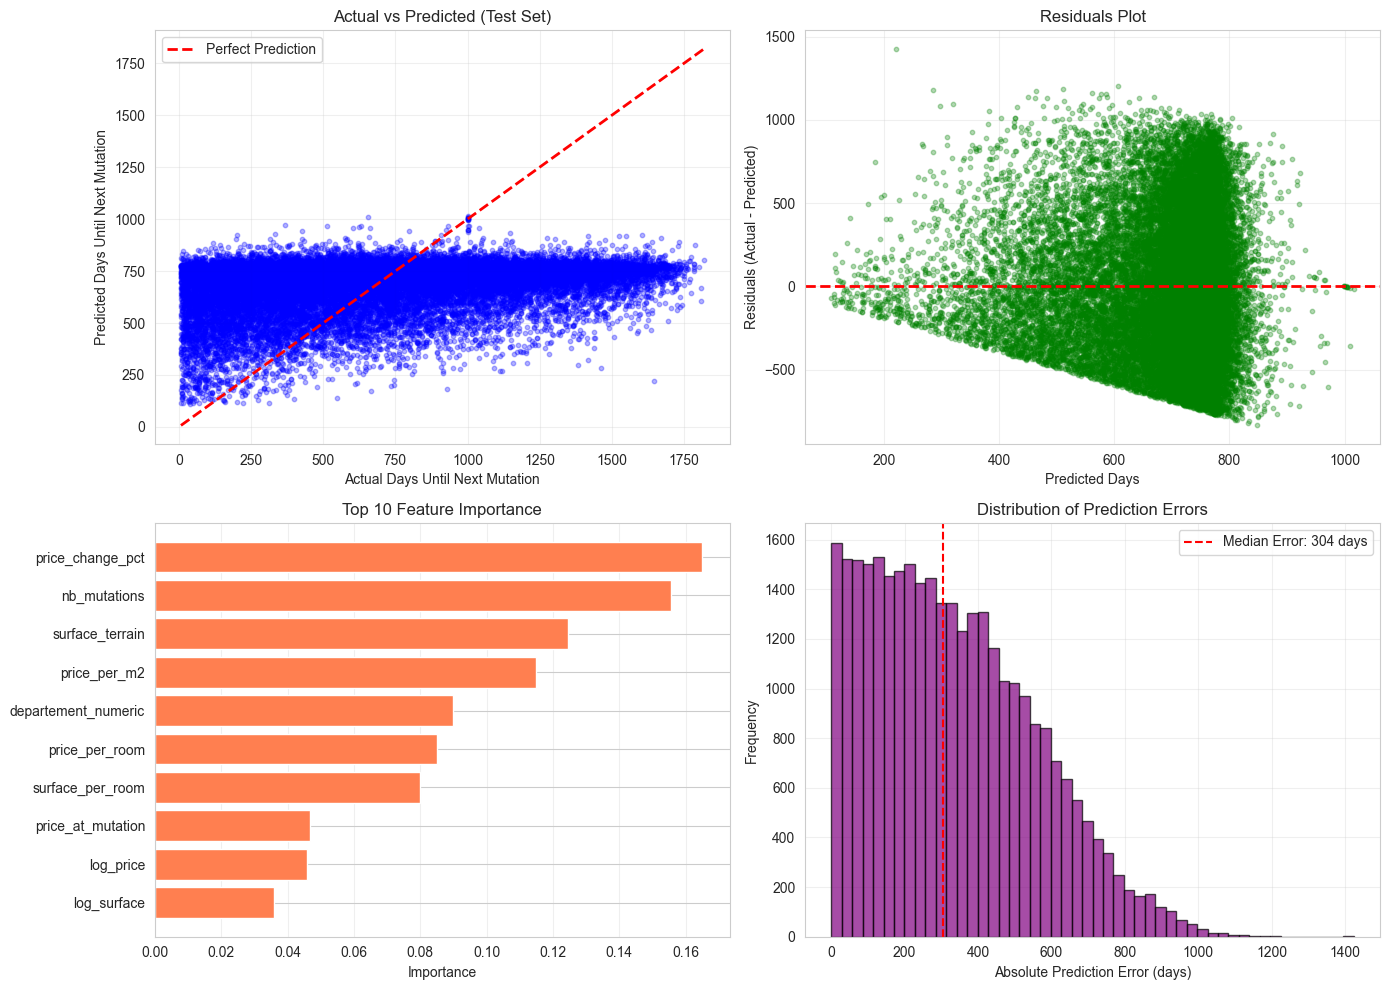


Prediction Error Statistics:
  - Median absolute error: 303.5 days (10.1 months)
  - Mean absolute error: 332.3 days (11.1 months)
  - 75th percentile: 486.2 days (16.2 months)
  - 90th percentile: 645.1 days (21.5 months)


In [141]:
# Visualization of model predictions
print("=" * 70)
print("MODEL PREDICTION VISUALIZATIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted (Test set)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Days Until Next Mutation')
axes[0, 0].set_ylabel('Predicted Days Until Next Mutation')
axes[0, 0].set_title('Actual vs Predicted (Test Set)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals plot
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.3, s=10, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Days')
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)')
axes[0, 1].set_title('Residuals Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature importance bar chart
top_features = feature_importance.head(10)
axes[1, 0].barh(range(len(top_features)), top_features['importance'], color='coral')
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['feature'])
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('Top 10 Feature Importance')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Distribution of prediction errors
prediction_errors = np.abs(residuals)
axes[1, 1].hist(prediction_errors, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].axvline(prediction_errors.median(), color='red', linestyle='--', 
                   label=f"Median Error: {prediction_errors.median():.0f} days")
axes[1, 1].set_xlabel('Absolute Prediction Error (days)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Prediction Errors')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrediction Error Statistics:")
print(f"  - Median absolute error: {prediction_errors.median():.1f} days ({prediction_errors.median()/30:.1f} months)")
print(f"  - Mean absolute error: {prediction_errors.mean():.1f} days ({prediction_errors.mean()/30:.1f} months)")
print(f"  - 75th percentile: {prediction_errors.quantile(0.75):.1f} days ({prediction_errors.quantile(0.75)/30:.1f} months)")
print(f"  - 90th percentile: {prediction_errors.quantile(0.90):.1f} days ({prediction_errors.quantile(0.90)/30:.1f} months)")

In [142]:
dept_summary = df.groupby('Code departement').agg(
    nb_properties=('last_price', 'count'),
    median_price=('last_price', 'median'),
    mean_price=('last_price', 'mean'),
    median_surface=('Surface reelle bati', 'median'),
    median_terrain=('Surface terrain', 'median'),
    median_rooms=('Nombre pieces principales', 'median'),
    median_price_m2=('price_per_m2', 'median')
).round(0).sort_values('median_price', ascending=False)

print("Top 15 departments by median price:")
dept_summary.head(15)

Top 15 departments by median price:


,nb_properties,median_price,mean_price,median_surface,median_terrain,median_rooms,median_price_m2
Code departement,,,,,,,
75,802,1650000.0,3078945.0,118.0,120.0,5.0,15057.0
92,11791,838150.0,1064571.0,102.0,259.0,4.0,8183.0
6,20341,550000.0,1001734.0,105.0,500.0,4.0,5231.0
94,17505,490000.0,618380.0,91.0,327.0,4.0,5488.0
2A,3664,459200.0,717738.0,100.0,925.0,4.0,4586.0
74,22051,451435.0,600029.0,104.0,604.0,4.0,4410.0
78,37439,400000.0,570869.0,102.0,426.0,5.0,3940.0
83,46166,399000.0,642322.0,99.0,500.0,4.0,4057.0
69,31254,383425.0,467822.0,102.0,504.0,4.0,3813.0


*Interpretation — Prediction Error Statistics**

These metrics measure how far off the predicted time-to-sale (days until next mutation) is from the actual time.

**What each metric means:**

- **Median absolute error: 303.5 days (10.1 months)**: Half of all predictions are within ~10 months of the actual time. This is a robust metric (less affected by outliers than the mean) and reflects typical model performance.

- **Mean absolute error: 332.3 days (11.1 months)**: On average, predictions are off by ~11 months. Slightly higher than the median, indicating some predictions have larger errors that pull the mean up.

- **75th percentile: 486.2 days (16.2 months)**: 75% of predictions are within ~16 months of the actual time. This gives a sense of the spread of errors.

- **90th percentile: 645.1 days (21.5 months)**: 90% of predictions are within ~21.5 months of the actual time. This captures the tail of the error distribution—10% of predictions have errors larger than ~21.5 months.

**Assessment:**

**Is this good performance?**
- Typical time-to-sale varies significantly by market (often 2-6 months in active markets, longer in slower markets).
- If typical durations are 6-12 months, a ~10-11 month median error is substantial relative to the target.
- If typical durations are 2-3 years, a ~10-11 month error is more reasonable.

**Practical implications:**
- Useful for rough estimates (e.g., "likely within 6-18 months").
- Less reliable for precise timing (e.g., "will sell in exactly 8 months").
- The model captures general patterns but struggles with precise timing.

**Recommendations:**
- Compare errors to the median/mean actual duration to assess relative performance.
- Consider stratified analysis (e.g., by price range, location, market conditions).
- Investigate the 10% with errors >21.5 months for systematic issues.